![lop](../../images/logo_diive1_128px.png)

<span style='font-size:40px; display:block;'>
<b>
    Flux Processing Chain
</b>
</br>
  
</span>
<p>Post-processing of EddyPro <i>_fluxnet_</i> output files</p>

---
**Notebook version**: `9.1` (4 Mar 2025)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)  

</br>

</br>

---

# **BACKGROUND**

---

- This notebook demonstrates part of the flux post-processing used for fluxes from Swiss FluxNet research stations
- For a description of the different flux levels, see [Flux Processing Chain](https://www.swissfluxnet.ethz.ch/index.php/data/ecosystem-fluxes/flux-processing-chain/)
- Flux calculations (Level-1) were done in a previous step
- This notebook uses the calculated fluxes (Level-1) and applies several post-processing steps:
    - Quality flag extension (Level-2)
    - Storage correction (Level-3.1)
    - Outlier removal (Level-3.2)
    - USTAR filtering (Level-3.3) - needs *known* thresholds from separate analysis, e.g. from FLUXNET
    - Gap-filling (Level-4.1) for flux using multiple methods ([MDS](../GapFilling/FluxMDSGapFilling.ipynb), [long-term random forest](../GapFilling/LongTermRandomForestGapFilling.ipynb))
- Other flux levels are currently not produced in this example:
    
    - NEE Partitioning (Level-4.2)
 
**Important**
- Flux variable names in the input files should follow the [FLUXNET convention](https://fluxnet.org/data/fluxnet2015-dataset/fullset-data-product/)

</br>

</br>

---

# **GENERAL SETTINGS**

---

## Flux variable
`FLUXVAR` is the name of the flux variable in the data files. In the EddyPro `_fluxnet_` output files, the flux variables we primarily use are:
  - `FC` ... CO2 flux, becomes `NEE` after storage correction (Level-3.1)
  - `LE` ... Latent heat flux (water)
  - `H` ... Sensible heat flux
  - `FN2O` ... Nitrous oxide flux
  - `FCH4` ... Methane flux
  
There are more flux variables in the output file, but we rarely need them:
  - `FH2O` ... H2O flux, very important but it is the same as `ET` and `LE` but with different units
  - `ET` ... Evapotranspiration, very important but it is the same as `FH2O` and `LE` but with different units. We can easily calculte `ET` later from `LE`, e.g. in `ReddyProc`.
  - `TAU` ... Momentum flux, a measure of the turbulent transfer of momentum between the land surface and the atmosphere

Set the name of the flux variable in the output file(s), must use the FLUXNET naming convention, e.g. FC, FH2O, LE, ET, H, FN2O, FCH4:

In [1]:
FLUXVAR = "FC"

## Site location
- Latitude and longitude of the site where data were recorded. This info is mainly used to calculate potential radiation, which is then used to divide the dataset into daytime and nighttime data.
- UTC offset of the timestamp used in the dataset, important for calculating potential radiation for this location with the correct timestamp.

In [2]:
SITE_LAT = 47.478333   # CH-LAE
SITE_LON = 8.364389  # CH-LAE
UTC_OFFSET = 1  # Time stamp offset in relation to UTC, e.g. 1 for UTC+01:00 (CET), important for the calculation of potential radiation for detecting daytime and nighttime

## Daytime/nighttime
- Threshold for potential radiation in `W m-2`, records below threshold are considered nighttime

In [3]:
NIGHTTIME_THRESHOLD = 20

## Quality requirements
- The default setting is to accept highest-quality and medium-quality fluxes for daytime (overall quality flag `QCF` = 0 or 1), and highest-quality fluxes only for nighttime (flag `QCF` = 0)
- `DAYTIME_ACCEPT_QCF_BELOW = 2` accepts high- (`QCF=0`) and medium-quality (`QCF=1`) fluxes for *daytime*, rejects low-quality (`QCF=2`) fluxes
- `NIGHTTIMETIME_ACCEPT_QCF_BELOW = 1` accepts high-quality (`QCF=0`) fluxes for *nighttime*, rejects medium-quality (`QCF=1`) and low-quality (`QCF=2`) fluxes
- This strict quality-filtering removes a lot of data points during nighttime

In [4]:
DAYTIME_ACCEPT_QCF_BELOW = 2
NIGHTTIMETIME_ACCEPT_QCF_BELOW = 2

</br>

---

# **IMPORTS**

---

- This notebook uses `diive` ([source code](https://github.com/holukas/diive)) to check eddy covariance fluxes for quality

In [5]:
import importlib.metadata
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats
import seaborn as sns

from diive.core.dfun.stats import sstats  # Time series stats
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.timeseries import TimeSeries  # For simple (interactive) time series plotting
from diive.pkgs.flux.hqflux import analyze_highest_quality_flux
from diive.pkgs.fluxprocessingchain.fluxprocessingchain import FluxProcessingChain
from diive.pkgs.fluxprocessingchain.fluxprocessingchain import LoadEddyProOutputFiles

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.90.0


</br>

</br>

---

# **DOCSTRING** for `FluxProcessingChain`

---

In [6]:
# help(FluxProcessingChain)

</br>

</br>

---

# **LOAD DATA** (2 options)

---

- It is possible to load data from (multiple) EddyPro _fluxnet_ output files (data from files will be merged), or directly from one single [parquet](https://parquet.apache.org/) file.
- parquet files are a good option for large datasets because they load and save much faster than when using conventional CSV files.
- For large datasets, it makes sense to first load and merge data from the original EddyPro _fluxnet_ output files, then convert the merged data to one single parquet file and then use this file as input file.

</br>

## Option 1: Load data from single or multiple EddyPro *_fluxnet_* output files
- Used to read data from the EddyPro _fluxnet_ output files
- Found files will be merged together into one single dataframe (`maindf`)

If you want to search for EddyPro _fluxnet_ files in specific locations, you can specify multiple folders here:

In [7]:
# # Folder(s) where input file(s) are located
# SOURCEDIRS = [r'example_data/']  

In [8]:
# ep = LoadEddyProOutputFiles(sourcedir=SOURCEDIRS, filetype='EDDYPRO-FLUXNET-CSV-30MIN')
# ep.searchfiles()
# ep.loadfiles()
# maindf = ep.maindf
# metadata = ep.metadata

</br>

## Option 2: Load data from `parquet` file
- Can be used to continue a previous session where another flux variable was already post-processed
- For example, if you have already post-processed CO2 flux and now want to post-process H2O flux
- Also detects time resolution of time series, this info was lost when saving to the parquet file

If you want to load data directly from a specific parquet file, you can specify its name and location here:

In [9]:
SOURCEDIR = r"../20_MERGE_DATA"
FILENAME = r"21.4_FLUXES_L1_noSHC_IRGA75+METEO7.parquet"
FILEPATH = Path(SOURCEDIR) / FILENAME
print(f"Data will be loaded from the following file:\n{FILEPATH}")

Data will be loaded from the following file:
..\20_MERGE_DATA\21.4_FLUXES_L1_noSHC_IRGA75+METEO7.parquet


In [10]:
maindf = load_parquet(filepath=FILEPATH)

Loaded .parquet file ..\20_MERGE_DATA\21.4_FLUXES_L1_noSHC_IRGA75+METEO7.parquet (1.775 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


In [11]:
[print(c) for c in maindf.columns if "TA" in c]

AXES_ROTATION_METHOD
CUSTOM_DATA_SIZE_IRGA72_MEAN
CUSTOM_DATA_SIZE_IRGA75_MEAN
CUSTOM_STATUS_CODE_IRGA72_MEAN
CUSTOM_STATUS_CODE_IRGA75_MEAN
DENTRENDING_TIME_CONSTANT
DOY_START
ET_STAGE1
ET_STAGE2
FC_STAGE1
FC_STAGE2
FH2O_STAGE1
FH2O_STAGE2
H_STAGE1
H_STAGE2
LE_STAGE1
LE_STAGE2
TAU
TAU_CORRDIFF
TAU_NR
TAU_NSR
TAU_RANDUNC_HF
TAU_SCF
TAU_SS
TAU_SSITC_TEST
TAU_SS_TEST
TAU_STAGE1
TAU_STAGE2
TAU_UNCORR
TA_EP
TA_T1_47_1
TA_T1_47_1_gfXG
TIMESTAMP_START
TSTAR
USTAR
USTAR_UNCORR


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

</br>

## Option 3: Load example data

In [12]:
# from diive.configs.exampledata import load_exampledata_EDDYPRO_FLUXNET_CSV_30MIN
# maindf, metadata = load_exampledata_EDDYPRO_FLUXNET_CSV_30MIN()

</br>

## (Optional) Restrict data to time range

In [13]:
# # Restrict data range
# maindf = maindf.loc[(maindf.index.year >= 2015) & (maindf.index.year <= 2017)].copy()

</br>

## Check data

In [14]:
display(maindf.head(3))
display(maindf.tail(3))
display(sstats(maindf[FLUXVAR]))

,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,...,W_UNROT,W_U_COV,W_VM97_TEST,W_ZCD,ZL,ZL_UNCORR
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2005-01-01 00:15:00,1008.03,1.19492,0.024191,1204.51,0.0,1.0,...,0.045938,-0.105746,800000000.0,11.0,0.118888,0.137374
2005-01-01 00:45:00,1008.11,1.19419,0.024204,1203.88,0.0,1.0,...,0.403188,-0.423825,800000000.0,5.0,-0.044524,-0.048667
2005-01-01 01:15:00,1008.17,1.19318,0.024223,1202.93,0.0,1.0,...,0.189884,-0.266300,800000000.0,7.0,-0.011929,-0.012089


,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,...,W_UNROT,W_U_COV,W_VM97_TEST,W_ZCD,ZL,ZL_UNCORR
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2019-12-31 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN
2019-12-31 23:15:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN
2019-12-31 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN


,FC
STARTDATE,2005-01-01 00:15
ENDDATE,2019-12-31 23:45
PERIOD,5477 days 23:30:00
NOV,207547
MISSING,55397
MISSING_PERC,21.067984
MEAN,-3.409604
MEDIAN,-0.734627
SD,91.858768
VAR,8438.03335


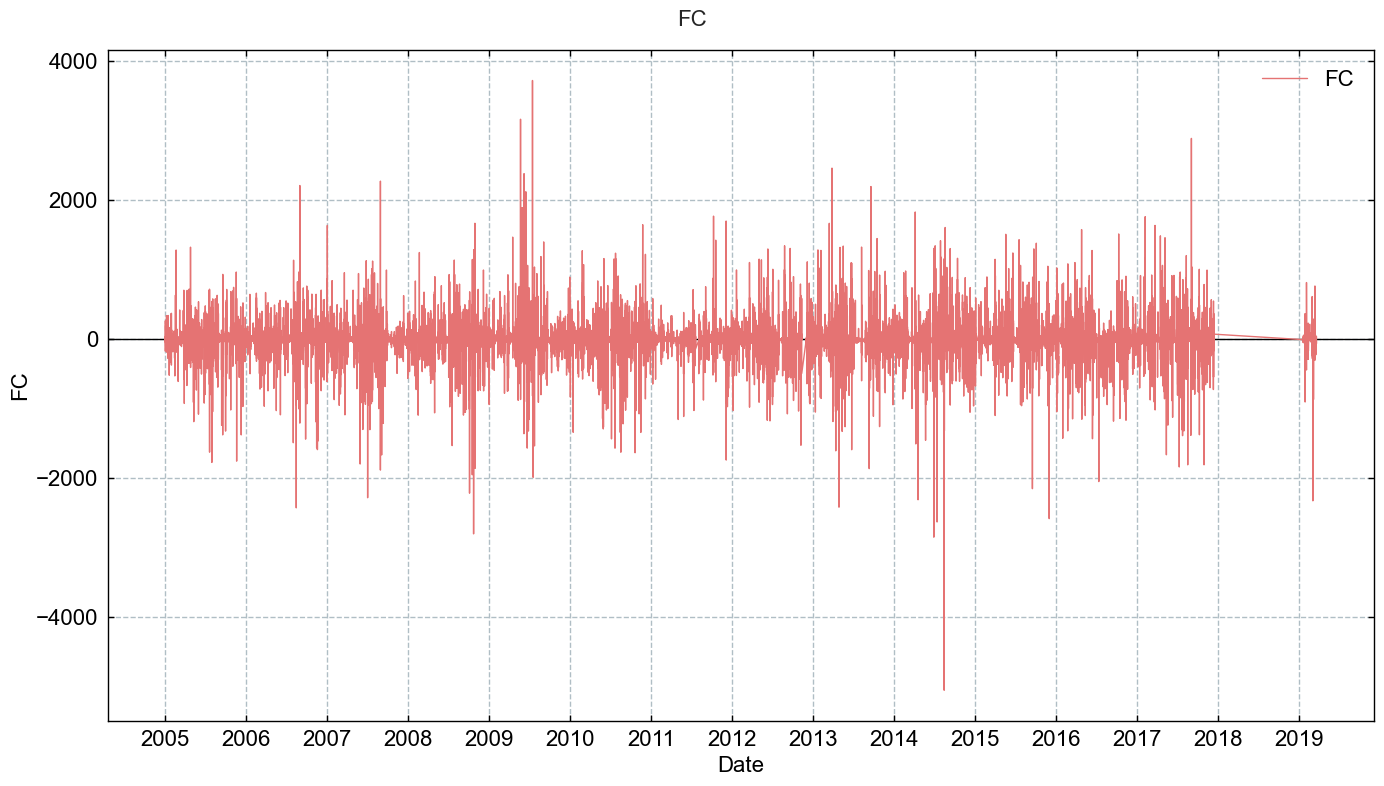

In [15]:
# TimeSeries(series=maindf[FLUXVAR]).plot_interactive()
TimeSeries(series=maindf[FLUXVAR]).plot()

</br>

</br>

---

# **START FLUX PROCESSING CHAIN**

---

- First we need to initialize the processing chain by providing some basic info.
- At the same time, some fundamental variables are also created: potential radiation, and two flags based on it: daytime flag (1=daytime) and nighttime flag (1=nighttime).

In [16]:
fpc = FluxProcessingChain(
    df=maindf,
    fluxcol=FLUXVAR,
    site_lat=SITE_LAT,
    site_lon=SITE_LON,
    utc_offset=UTC_OFFSET,    
    nighttime_threshold=NIGHTTIME_THRESHOLD,
    daytime_accept_qcf_below=DAYTIME_ACCEPT_QCF_BELOW,
    nighttimetime_accept_qcf_below=NIGHTTIMETIME_ACCEPT_QCF_BELOW
)

Detected base variable CO2 for FC. (CO2 was used to calculate FC.)
Calculated potential radiation from latitude and longitude (SW_IN_POT) ... 
Calculated daytime flag DAYTIME and nighttime flag NIGHTTIME from SW_IN_POT ...
++ Added new column SW_IN_POT to input data.  (!) Existing SW_IN_POT in input data is overwritten.
++ Added new column DAYTIME to input data.
++ Added new column NIGHTTIME to input data.


- Let's check the flux processing chain dataframe: this are the data the chain is working with in this run:

In [17]:
fpc.fpc_df

,FC,USTAR,SW_IN_POT,DAYTIME,NIGHTTIME
TIMESTAMP_MIDDLE,,,,,
2005-01-01 00:15:00,41.81640,0.388239,0.0,0.0,1.0
2005-01-01 00:45:00,-22.23130,0.657366,0.0,0.0,1.0
2005-01-01 01:15:00,-9.51296,0.520923,0.0,0.0,1.0
2005-01-01 01:45:00,-1.29971,0.522629,0.0,0.0,1.0
2005-01-01 02:15:00,-7.25724,0.447028,0.0,0.0,1.0
...,...,...,...,...,...
2019-12-31 21:45:00,NaN,NaN,0.0,0.0,1.0
2019-12-31 22:15:00,NaN,NaN,0.0,0.0,1.0
2019-12-31 22:45:00,NaN,NaN,0.0,0.0,1.0


</br>

</br>

---

# Level-2: **QUALITY FLAG EXTENSION**

---

> Extract additional quality information from the EddyPro output and store it in newly added quality flags.



Note that the USTAR filtering is not part of the Level-2 calculations.

</br>

## User settings
- A test for missing values is always included: flag calculated here from missing flux values in the EddyPro output file

</br>

### SSITC tests (default: `True`)
- Flag calculated in EddyPro
- Combination of the two partial tests *steady state test* and *developed turbulent conditions test*
- This notebook expects the SSITC flag to follow the flagging policy according to Mauder and Foken 2004:
    - `0` for best quality fluxes
    - `1` for fluxes suitable for general analysis such as annual budgets (although this is debatable for nighttime data)
    - `2` for fluxes that should be discarded from the dataset

In [18]:
TEST_SSITC = True  # Default True
TEST_SSITC_SETFLAG_TIMEPERIOD = False  # {2: [[1, '2022-05-01', '2023-09-30']]}

</br>

### Flux base variable completeness test (default: `True`)
- Flag newly calculated here
- Check completeness of the variable that was used to calculate the respective flux
- Example: `CO2` is the base variable that was used to calculate flux `FC`, the test is therefore run on `CO2`
- Checks number of records of the relevant base variable available for each averaging Interval and calculates completeness flag as follows:
    - `0` for files where >= 99% of base variable are available
    - `1` for files where >= 97% and < 99% of base variable are available
    - `2` for files where < 97% of base variable are available
 
List of flux base variables and the corresponding fluxes:
- `CO2`: used to calculate `FC`
- `H2O`: used to calculate `FH2O`
- `H2O`: used to calculate `LE`
- `H2O`: used to calculate `ET`
- `T_SONIC`: used to calculate `H`
- `N2O`: used to calculate `FN2O`
- `CH4`: used to calculate `FCH4`

In [19]:
TEST_GAS_COMPLETENESS = True  # Default True

</br>

### Spectral correction factor test (default: `True`)
- Flag calculated here from the gas `SCF` variable in EddyPro output file

In [20]:
TEST_SPECTRAL_CORRECTION_FACTOR = True  # Default True

</br>

### Signal strength test

<div class="alert alert-block alert-info">
<b>Always recommended if flux was calculated using a gas analyzer.</b>
</div>  

<div class="alert alert-block alert-danger">
<b>Do not use for H (sensible heat flux).</b> This test is only relevant for fluxes where the concentration/temperature was measured by a gas analyzer, e.g. FC, FH2O, LE, ET, N2O, CH4, etc ... 
</div>  

- Signal strength / AGC / window dirtiness test (if available)
- Flag calculated here from the signal strength / AGC variable for the gas analyzer in EddyPro output file
- `SIGNAL_STRENGTH_COL`: Name of the column storing the signal strength, typically 'CUSTOM_AGC_MEAN' for LI-7500, 'CUSTOM_SIGNAL_STRENGTH_IRGA72_MEAN' for LI-7200, or something similar
- `SIGNAL_STRENGTH_THRESHOLD`: Signal strength threshold, flux values where threshold is exceeded are flagged as rejected
- `SIGNAL_STRENGTH_METHOD`: `discard above` flags fluxes where signal strength > threshold, `discard below` where signal strength < threshold

In [21]:
# Signal strength
TEST_SIGNAL_STRENGTH = True
TEST_SIGNAL_STRENGTH_COL = 'CUSTOM_AGC_IRGA75_MEAN'  # Typical variable name in fluxnet files
TEST_SIGNAL_STRENGTH_METHOD = 'discard above'
TEST_SIGNAL_STRENGTH_THRESHOLD = 90

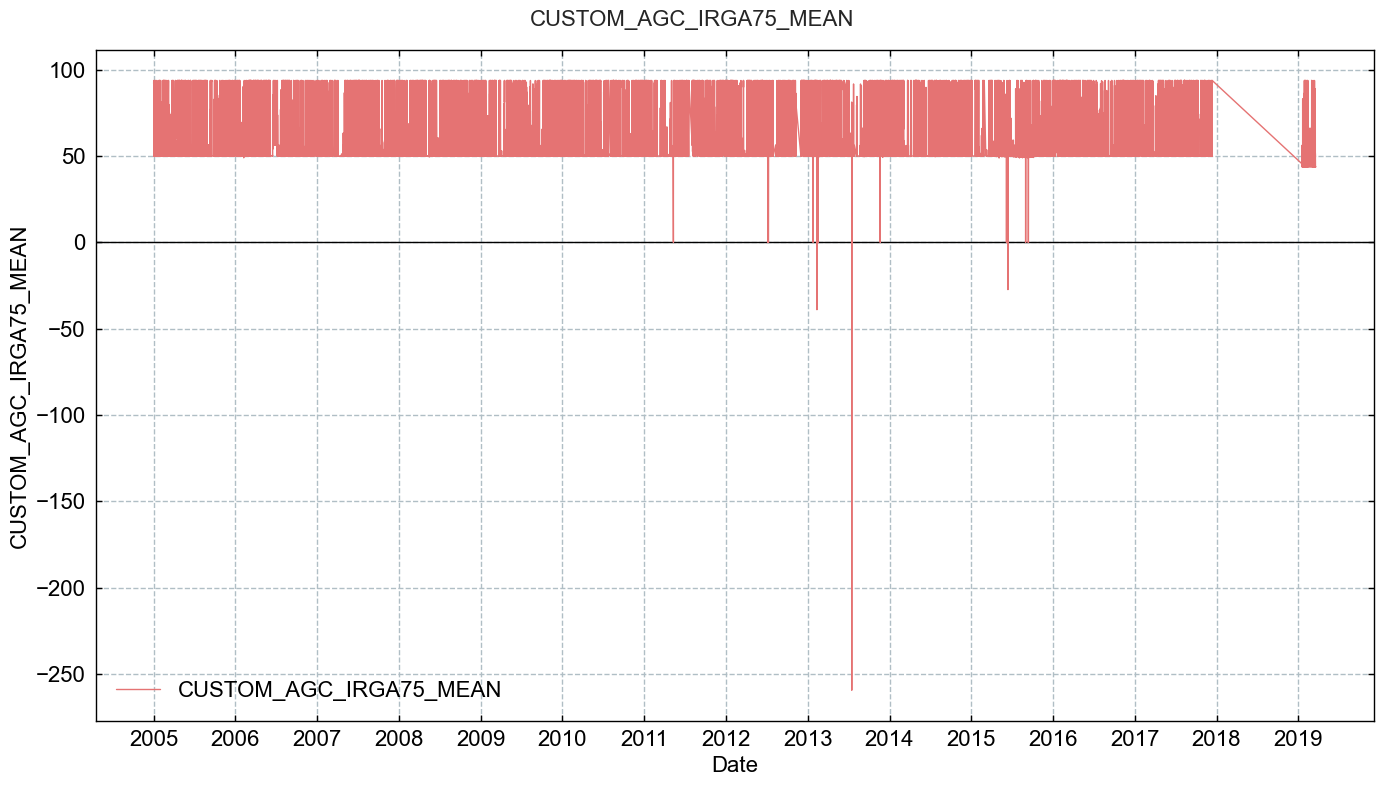

In [22]:
# TimeSeries(series=df_orig[SIGNAL_STRENGTH_COL]).plot_interactive()
TimeSeries(series=maindf[TEST_SIGNAL_STRENGTH_COL]).plot()

</br>

### Raw data screening tests
- Flags were calculated in EddyPro
- See here for more details: [Despiking and raw data statistical screening (EddyPro help)](https://www.licor.com/env/support/EddyPro/topics/despiking-raw-statistical-screening.html)

In [23]:
TEST_RAWDATA = True  # Default True
TEST_RAWDATA_SPIKES = True  # Default True
TEST_RAWDATA_AMPLITUDE = True  # Default True
TEST_RAWDATA_DROPOUT = True  # Default True
TEST_RAWDATA_ABSLIM = False  # Default False
TEST_RAWDATA_SKEWKURT_HF = False  # Default False
TEST_RAWDATA_SKEWKURT_SF = False  # Default False
TEST_RAWDATA_DISCONT_HF = False  # Default False
TEST_RAWDATA_DISCONT_SF = False  # Default False

</br>

### Angle-of-attack test (default: `False`)
> This test calculates sample-wise Angle of Attacks throughout the current flux averaging period, and flags it if the percentage of angles of attack exceeding a user-defined range is beyond a (user-defined) threshold.  
> Source: [EddyPro help](https://www.licor.com/env/support/EddyPro/topics/despiking-raw-statistical-screening.html?Highlight=angle%20of%20attack#Angleofattack)  *(3 Jan 2024)*
- Flag was calculated in EddyPro
- Flag can be useful during some time periods when the sonic anemometer had issues
- Not used by default (similar to ICOS)

In [24]:
TEST_RAWDATA_ANGLE_OF_ATTACK = False  # Default False
TEST_RAWDATA_ANGLE_OF_ATTACK_APPLICATION_DATES = []
# TEST_RAWDATA_ANGLE_OF_ATTACK_APPLICATION_DATES = [['2008-01-01', '2010-01-01'],
#                                                   ['2016-03-01', '2016-05-01'],
#                                                   ['2021-12-10', '2021-12-23']]

</br>

### Steadiness of horizontal wind test (default: `False`)
> This test assesses whether the along-wind and crosswind components of the wind vector undergo a systematic reduction (or increase) throughout the file. If the quadratic combination of such systematic variations is beyond the user-selected limit, the flux averaging period is hard-flagged for instationary horizontal wind (Vickers and Mahrt, 1997, Par. 6g).  
> Source: [EddyPro help](https://www.licor.com/env/support/EddyPro/topics/despiking-raw-statistical-screening.html?Highlight=angle%20of%20attack#Steadinessofhorizontalwind)  *(3 Jan 2024)*
- Flag was calculated in EddyPro

In [25]:
TEST_RAWDATA_STEADINESS_OF_HORIZONTAL_WIND = False  # Default False

</br>

</br>

## Run

In [26]:
LEVEL2_SETTINGS = {
    'signal_strength': {
        'apply': TEST_SIGNAL_STRENGTH,
        'signal_strength_col': TEST_SIGNAL_STRENGTH_COL,
        'method': TEST_SIGNAL_STRENGTH_METHOD,
        'threshold': TEST_SIGNAL_STRENGTH_THRESHOLD},
    'raw_data_screening_vm97': {
        'apply': TEST_RAWDATA,
        'spikes': TEST_RAWDATA_SPIKES,
        'amplitude': TEST_RAWDATA_AMPLITUDE,
        'dropout': TEST_RAWDATA_DROPOUT,
        'abslim': TEST_RAWDATA_ABSLIM,
        'skewkurt_hf': TEST_RAWDATA_SKEWKURT_HF,
        'skewkurt_sf': TEST_RAWDATA_SKEWKURT_SF,
        'discont_hf': TEST_RAWDATA_DISCONT_HF,
        'discont_sf': TEST_RAWDATA_DISCONT_SF},
    'ssitc': {
        'apply': TEST_SSITC,
        'setflag_timeperiod': TEST_SSITC_SETFLAG_TIMEPERIOD},
    'gas_completeness': {
        'apply': TEST_GAS_COMPLETENESS},
    'spectral_correction_factor': {
        'apply': TEST_SPECTRAL_CORRECTION_FACTOR},
    'angle_of_attack': {
        'apply': TEST_RAWDATA_ANGLE_OF_ATTACK,
        'application_dates': TEST_RAWDATA_ANGLE_OF_ATTACK_APPLICATION_DATES},
    'steadiness_of_horizontal_wind': {
        'apply': TEST_RAWDATA_STEADINESS_OF_HORIZONTAL_WIND}
}
fpc.level2_quality_flag_expansion(**LEVEL2_SETTINGS)

[MissingValues]  running MissingValues ...
SSITC TEST: Generated new flag variable FLAG_L2_FC_SSITC_TEST, values taken from output variable FC_SSITC_TEST ...
FLUX BASE VARIABLE COMPLETENESS TEST: Generated new flag variable FLAG_L2_FC_COMPLETENESS_TEST, newly calculated from variable CO2, with flag 0 (good values) where available number of records for CO2 >= 0.99, flag 1 (ok values) >= 0.97 and < 0.99, flag 2 (bad values) < 0.97...
SPECTRAL CORRECTION FACTOR TEST: Generating new flag variable FLAG_L2_FC_SCF_TEST, newly calculated from output variable FC_SCF, withflag 0 (good values) where FC_SCF < 2, flag 1 (ok values) where FC_SCF >= 2 and < 4, flag 2 (bad values) where FC_SCF >= 4...
SIGNAL STRENGTH TEST: Generating new flag variable FLAG_L2_FC_SIGNAL_STRENGTH_TEST, newly calculated from output variable CUSTOM_AGC_IRGA75_MEAN, with flag 0 (good values) where CUSTOM_AGC_IRGA75_MEAN <= 90, flag 2 (bad values) where CUSTOM_AGC_IRGA75_MEAN > 90 ...
RAW DATA TEST: Generated new flag varia

</br>

</br>

## Finalize Level-2

In [27]:
fpc.finalize_level2()

++Added new column FLAG_L2_FC_MISSING_TEST.
++Added new column FLAG_L2_FC_SSITC_TEST.
++Added new column FLAG_L2_FC_COMPLETENESS_TEST.
++Added new column FLAG_L2_FC_SCF_TEST.
++Added new column FLAG_L2_FC_SIGNAL_STRENGTH_TEST.
++Added new column FLAG_L2_FC_CO2_VM97_SPIKE_HF_TEST.
++Added new column FLAG_L2_FC_CO2_VM97_AMPLITUDE_RESOLUTION_HF_TEST.
++Added new column FLAG_L2_FC_CO2_VM97_DROPOUT_TEST.
++Added new column SUM_L2_FC_HARDFLAGS.
++Added new column SUM_L2_FC_SOFTFLAGS.
++Added new column SUM_L2_FC_FLAGS.
++Added new column FLAG_L2_FC_QCF.
++Added new column FC_L2_QCF.
++Added new column FC_L2_QCF0.


</br>

### Available `Level-2` variables
- This shows all available Level-2 variables for this flux

In [28]:
[x for x in fpc.fpc_df.columns if 'L2' in x]

['FLAG_L2_FC_MISSING_TEST',
 'FLAG_L2_FC_SSITC_TEST',
 'FLAG_L2_FC_COMPLETENESS_TEST',
 'FLAG_L2_FC_SCF_TEST',
 'FLAG_L2_FC_SIGNAL_STRENGTH_TEST',
 'FLAG_L2_FC_CO2_VM97_SPIKE_HF_TEST',
 'FLAG_L2_FC_CO2_VM97_AMPLITUDE_RESOLUTION_HF_TEST',
 'FLAG_L2_FC_CO2_VM97_DROPOUT_TEST',
 'SUM_L2_FC_HARDFLAGS',
 'SUM_L2_FC_SOFTFLAGS',
 'SUM_L2_FC_FLAGS',
 'FLAG_L2_FC_QCF',
 'FC_L2_QCF',
 'FC_L2_QCF0']

</br>

### Plots

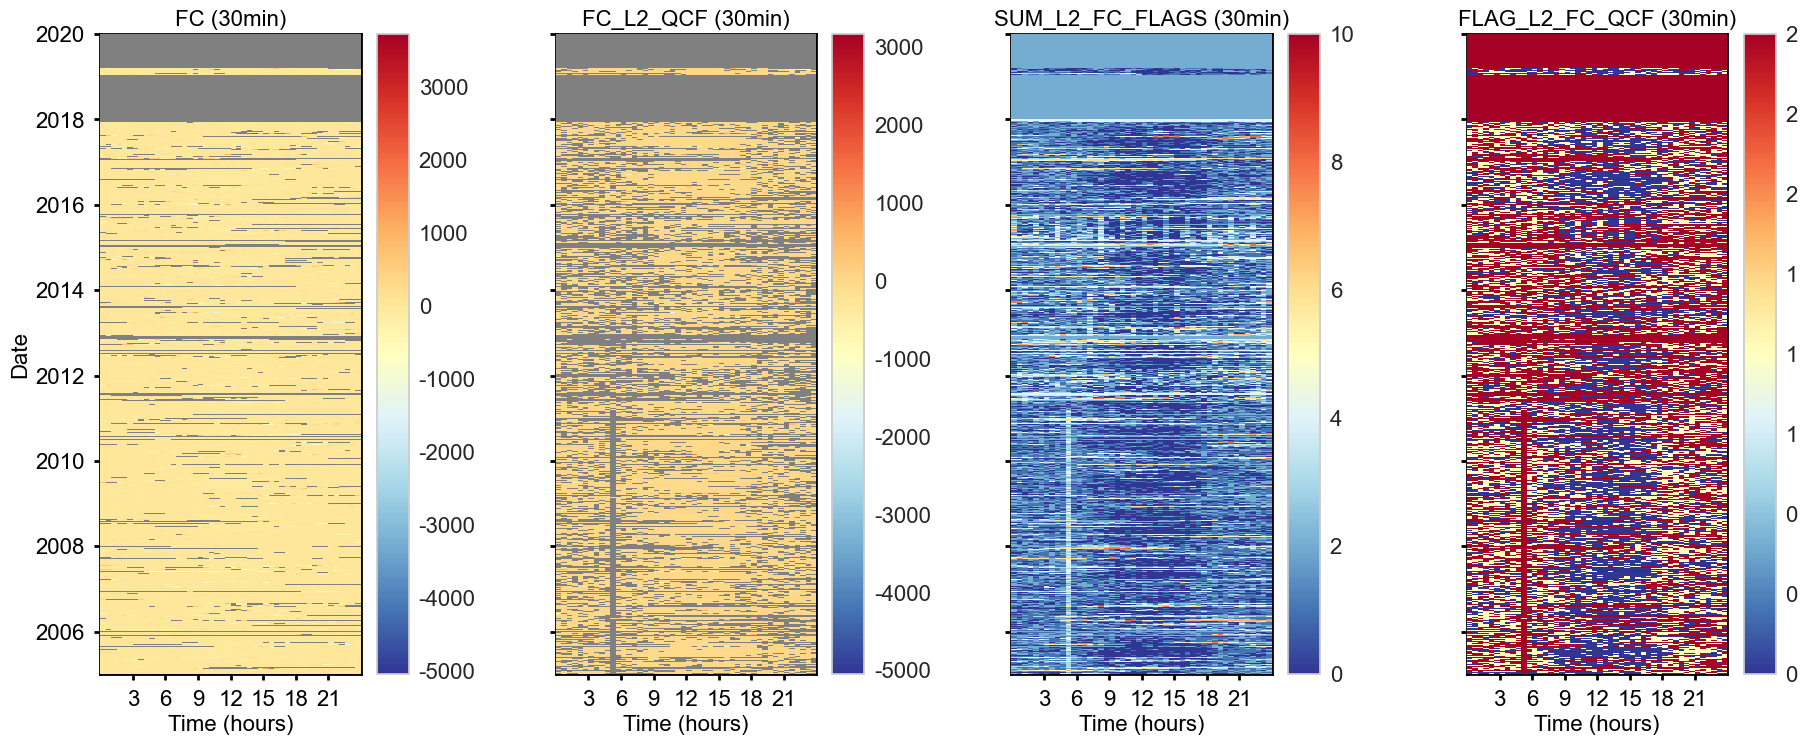

In [29]:
fpc.level2_qcf.showplot_qcf_heatmaps()

In [30]:
# fpc.level2_qcf.showplot_qcf_timeseries()

</br>

### Reports

In [31]:
fpc.level2_qcf.report_qcf_evolution()



QCF FLAG EVOLUTION
This output shows the evolution of the QCF overall quality flag
when test flags are applied sequentially to the variable FC.

Number of FC records before QC: 207547
+++ FLAG_L2_FC_MISSING_TEST rejected 0 values (+0.00%)      TOTALS: flag 0: 207547 (100.00%) / flag 1: 0 (0.00%) / flag 2: 0 (0.00%)
+++ FLAG_L2_FC_SSITC_TEST rejected 46180 values (+22.25%)      TOTALS: flag 0: 76967 (37.08%) / flag 1: 84400 (40.67%) / flag 2: 46180 (22.25%)
+++ FLAG_L2_FC_COMPLETENESS_TEST rejected 2049 values (+0.99%)      TOTALS: flag 0: 74743 (36.01%) / flag 1: 84575 (40.75%) / flag 2: 48229 (23.24%)
+++ FLAG_L2_FC_SCF_TEST rejected 0 values (+0.00%)      TOTALS: flag 0: 74743 (36.01%) / flag 1: 84575 (40.75%) / flag 2: 48229 (23.24%)
+++ FLAG_L2_FC_SIGNAL_STRENGTH_TEST rejected 10384 values (+5.00%)      TOTALS: flag 0: 71770 (34.58%) / flag 1: 77164 (37.18%) / flag 2: 58613 (28.24%)
+++ FLAG_L2_FC_CO2_VM97_SPIKE_HF_TEST rejected 1876 values (+0.90%)      TOTALS: flag 0: 71108 (34

In [32]:
fpc.level2_qcf.report_qcf_series()



SUMMARY: FLAG_L2_FC_QCF, QCF FLAG FOR FC
Between 2005-01-01 00:15 and 2019-12-31 23:45 ...
    Total flux records BEFORE quality checks: 207547 (78.93% of potential)
    Available flux records AFTER quality checks: 139399 (67.17% of total)
    Rejected flux records: 68148 (32.83% of total)
    Potential flux records: 262944
    Potential flux records missed: 55397 (21.07% of potential)



In [33]:
# fpc.level2_qcf.report_qcf_flags()

</br>

</br>

---

# Level-3.1: **STORAGE CORRECTION**

---

- The flux storage term (single point) is added to the flux
- For some records, the storage term can be missing. In such cases, missing terms are gap-filled using the rolling mean in an expanding window.
- Without gap-filling the storage term, we can lose an additional e.g. 2-3% of flux data

</br>

## Run

In [34]:
fpc.level31_storage_correction(gapfill_storage_term=True)

Detected storage variable SC_SINGLE for FC.
Calculating storage-corrected flux NEE_L3.1 from flux FC and storage term SC_SINGLE ...
Missing values for storage term SC_SINGLE_gfRMED_L3.1: 3782
Gap-filling storage-term SC_SINGLE with rolling median (window size = 5 records, centered)  |  still missing values for storage term SC_SINGLE_gfRMED_L3.1: 2850 ...
Gap-filling storage-term SC_SINGLE with rolling median (window size = 7 records, centered)  |  still missing values for storage term SC_SINGLE_gfRMED_L3.1: 1022 ...
Gap-filling storage-term SC_SINGLE with rolling median (window size = 9 records, centered)  |  still missing values for storage term SC_SINGLE_gfRMED_L3.1: 780 ...
Gap-filling storage-term SC_SINGLE with rolling median (window size = 11 records, centered)  |  still missing values for storage term SC_SINGLE_gfRMED_L3.1: 527 ...
Gap-filling storage-term SC_SINGLE with rolling median (window size = 13 records, centered)  |  still missing values for storage term SC_SINGLE_gfRME

</br>

## **Finalize Level-3.1**

In [35]:
fpc.finalize_level31()

++Added new column SC_SINGLE.
++Added new column SC_SINGLE_gfRMED_L3.1.
++Added new column FLAG_SC_SINGLE_gfRMED_L3.1_ISFILLED.
++Added new column NEE_L3.1.
++Added new column NEE_L3.1_QCF (Level-3.1 with applied quality flag from Level-2).
++Added new column NEE_L3.1_QCF0 (Level-3.1 with applied quality flag from Level-2).


</br>

### Available `Level-3.1` variables
- This shows all available Level-3.1 variables for this flux

In [36]:
[x for x in fpc.fpc_df.columns if 'L3.1' in x]

['SC_SINGLE_gfRMED_L3.1',
 'FLAG_SC_SINGLE_gfRMED_L3.1_ISFILLED',
 'NEE_L3.1',
 'NEE_L3.1_QCF',
 'NEE_L3.1_QCF0']

</br>

### Plots

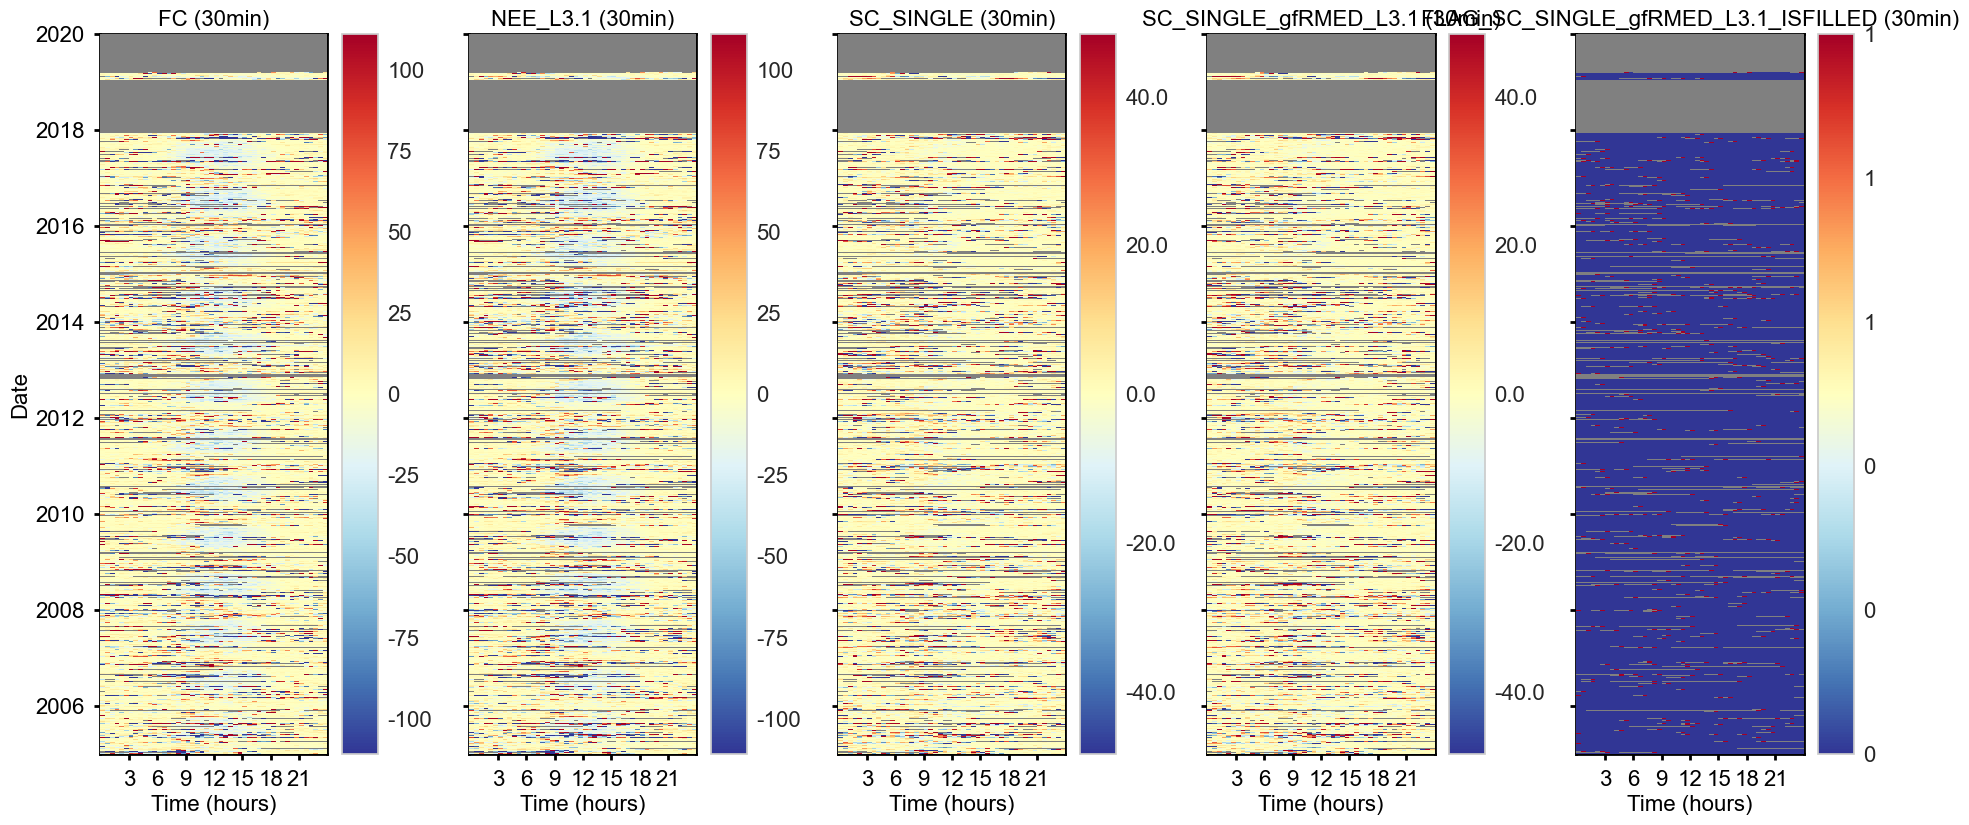

In [37]:
fpc.level31.showplot()

</br>

### Report

In [38]:
fpc.level31.report()


REPORT: STORAGE CORRECTION FOR FC
Swiss FluxNet processing chain, _L3.1: Storage Correction

The gap-filled storage term SC_SINGLE_gfRMED_L3.1 was added to flux FC.
The storage-corrected flux was stored as NEE_L3.1.

The flux was available for 207547 records (FC).
The original, non-gapfilled storage term was available for 203872 records (SC_SINGLE).
The original storage term SC_SINGLE was missing for 3782 flux records.
Without gap-filling the storage term (SC_SINGLE), 3782 measured flux records (FC) are lost.

For this run, gap-filling of SC_SINGLE was * SELECTED *.
After gap-filling the storage term, it was available for an additional 3782 records (SC_SINGLE_gfRMED_L3.1).

In the storage-corrected flux NEE_L3.1 with 207547 records, 
  - 98.2% (203872 records) of used storage terms come from originally calculated data (SC_SINGLE)
  - 1.8% (3782 records) of used storage terms come from gap-filled data (SC_SINGLE_gfRMED_L3.1)

Stats for gap-filled storage terms:
                        

</br>

---    

# Optional: **Analyze highest-quality flux** (so far)

---

- Analysis of fluxes after Level-3.1 where the overall quality flag `QCF` = 0
- This helps in understanding in what range the "true" flux occurs
- Here, the highest-quality fluxes are additionally filtered for outlier values using the relatively fast Local Outlier Factor test
- For this quick analysis, it is possible that the outlier test cuts off some "real" values that should be retained, but it nevertheless helps in understanding the flux range
- `QCF` = 0 is best quality, `QCF` = medium quality, `QCF` = 2 bad quality and always rejected
- The difference between quality 0 and quality 1 or 2 is huge


>>> Removing outliers from highest-quality DAYTIME fluxes (NEE_L3.1_QCF0)
>>> Outlier removal method: Local outlier factor across all data (n_neighbors=226, contamination=auto, repeat=False)
[LocalOutlierFactorAllData]  running LocalOutlierFactorAllData ...
ITERATION#1: Total found outliers: 301 values (daytime+nighttime)
>>> Largest non-outlier flux >= 0 DAYTIME:   146.697
>>> Smallest non-outlier flux >= 0 DAYTIME:  0.00042000000000008697
>>> Largest non-outlier flux < 0 DAYTIME:    -0.0008099999999999774
>>> Smallest non-outlier flux < 0 DAYTIME:   -172.7337
>>> Largest outlier flux >= 0 DAYTIME:   1147.6113
>>> Smallest outlier flux >= 0 DAYTIME:  147.63932
>>> Largest outlier flux < 0 DAYTIME:    -170.52868
>>> Smallest outlier flux < 0 DAYTIME:   -2218.002

>>> Removing outliers from highest-quality NIGHTTIME fluxes (NEE_L3.1_QCF0)
>>> Outlier removal method: Local outlier factor across all data (n_neighbors=113, contamination=auto, repeat=False)
[LocalOutlierFactorAllData]  run

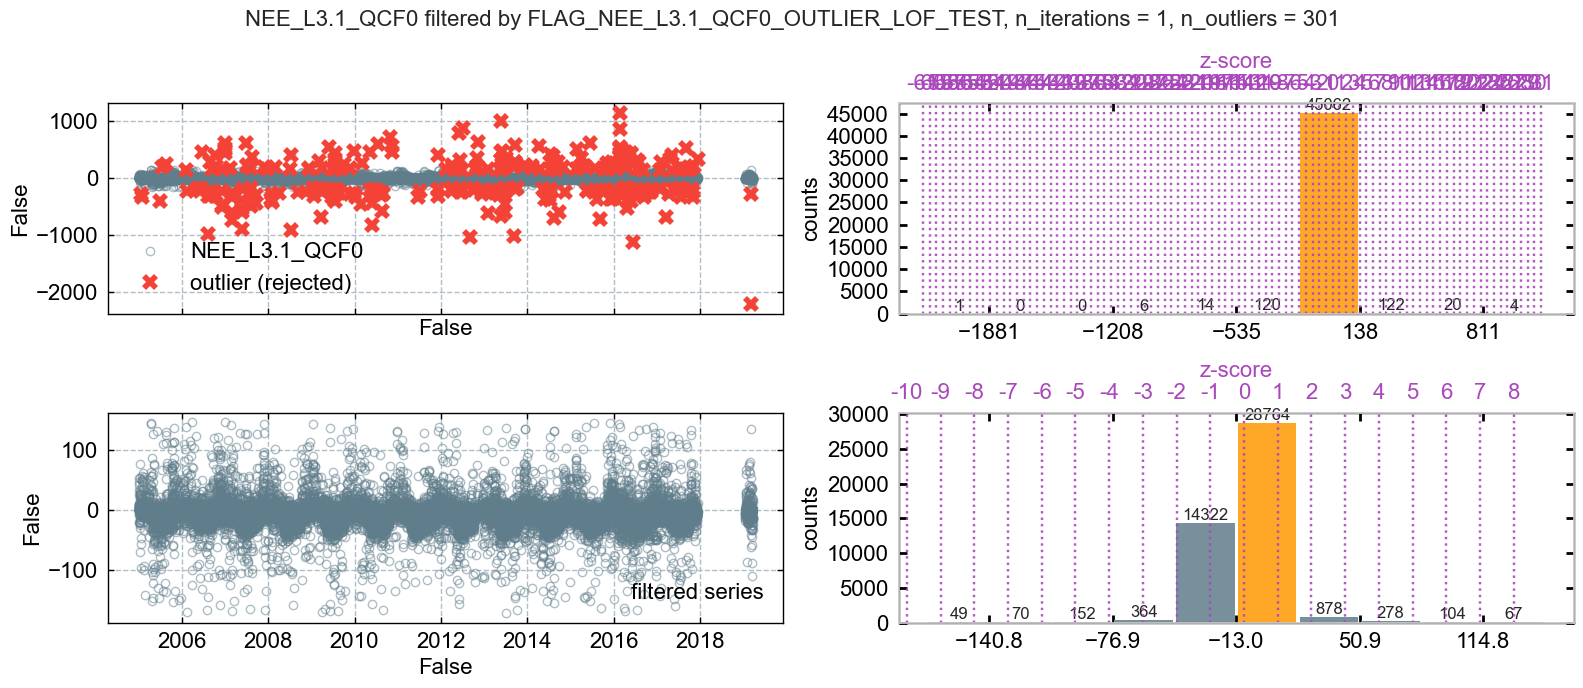

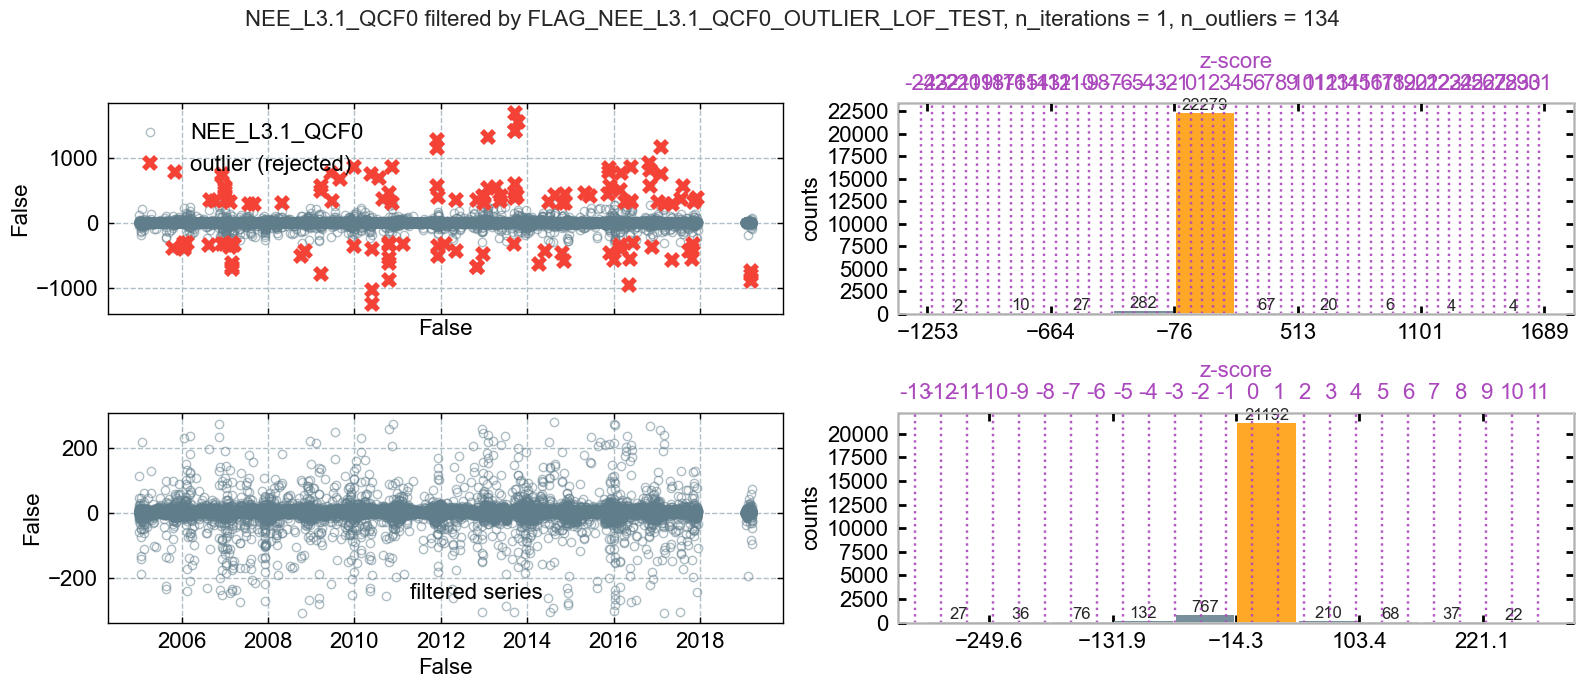

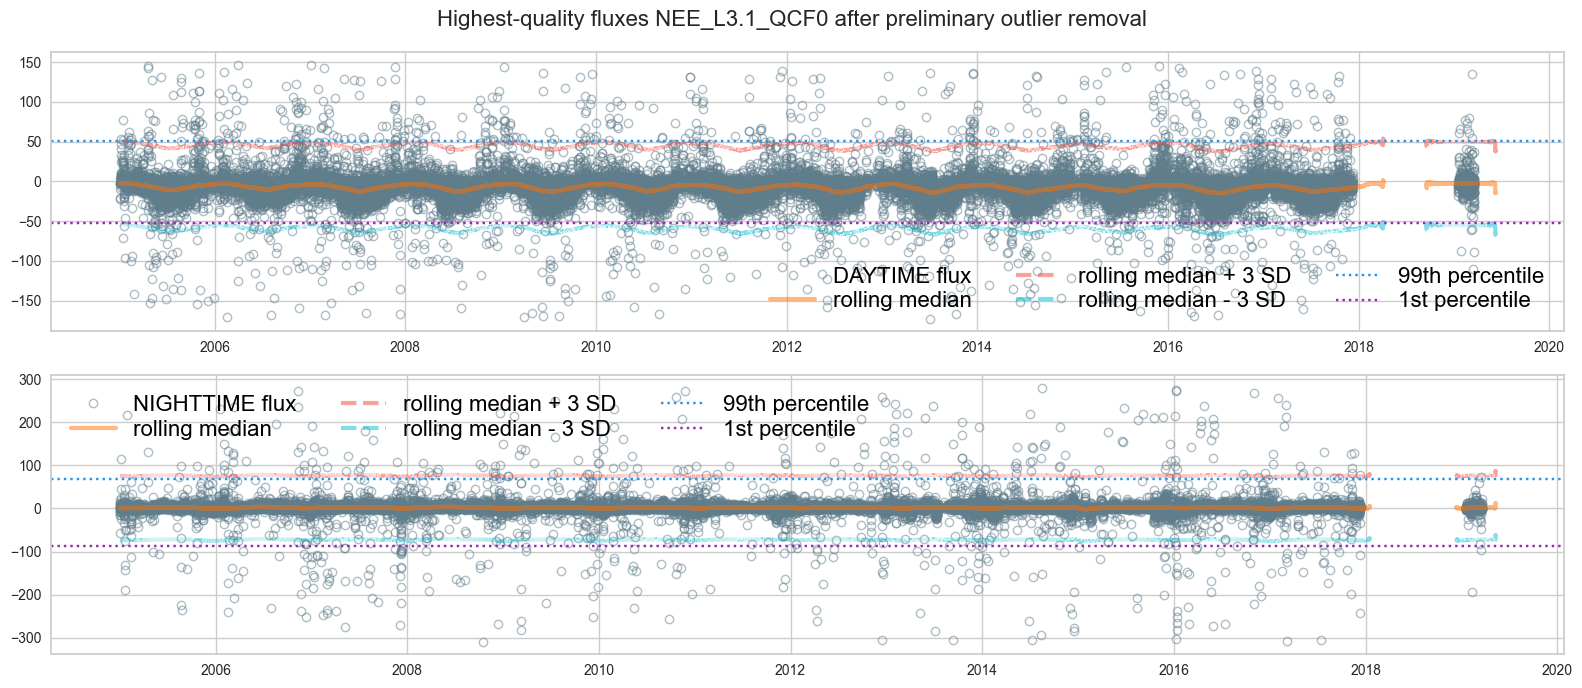

In [39]:
analyze_highest_quality_flux(flux=fpc.fpc_df[fpc.filteredseries_hq.name], nighttime_flag=fpc.fpc_df['NIGHTTIME'])

</br>

</br>

---

# Level-3.2: **OUTLIER DETECTION**

---

- Running an outlier test creates a *preview* plot of the results
- If the output looks as desired, run `fpc.level32_addflag()` cell below the preview to accept the results you see in the plot
- All subsequent tests will then be based on these results
- This means that each test is run on the data already filtered by the previous test
- Each test creates its own quality flag
- At the end of Level-3.2, an overall quality flag `QCF` is created that combines all of the individual flags into one single flag

</br>

## Plot time series

In [40]:
print(f"{fpc.filteredseries.name} \n(quality-controlled Level-3.1 version of {fpc.fluxcol})")

NEE_L3.1_QCF 
(quality-controlled Level-3.1 version of FC)


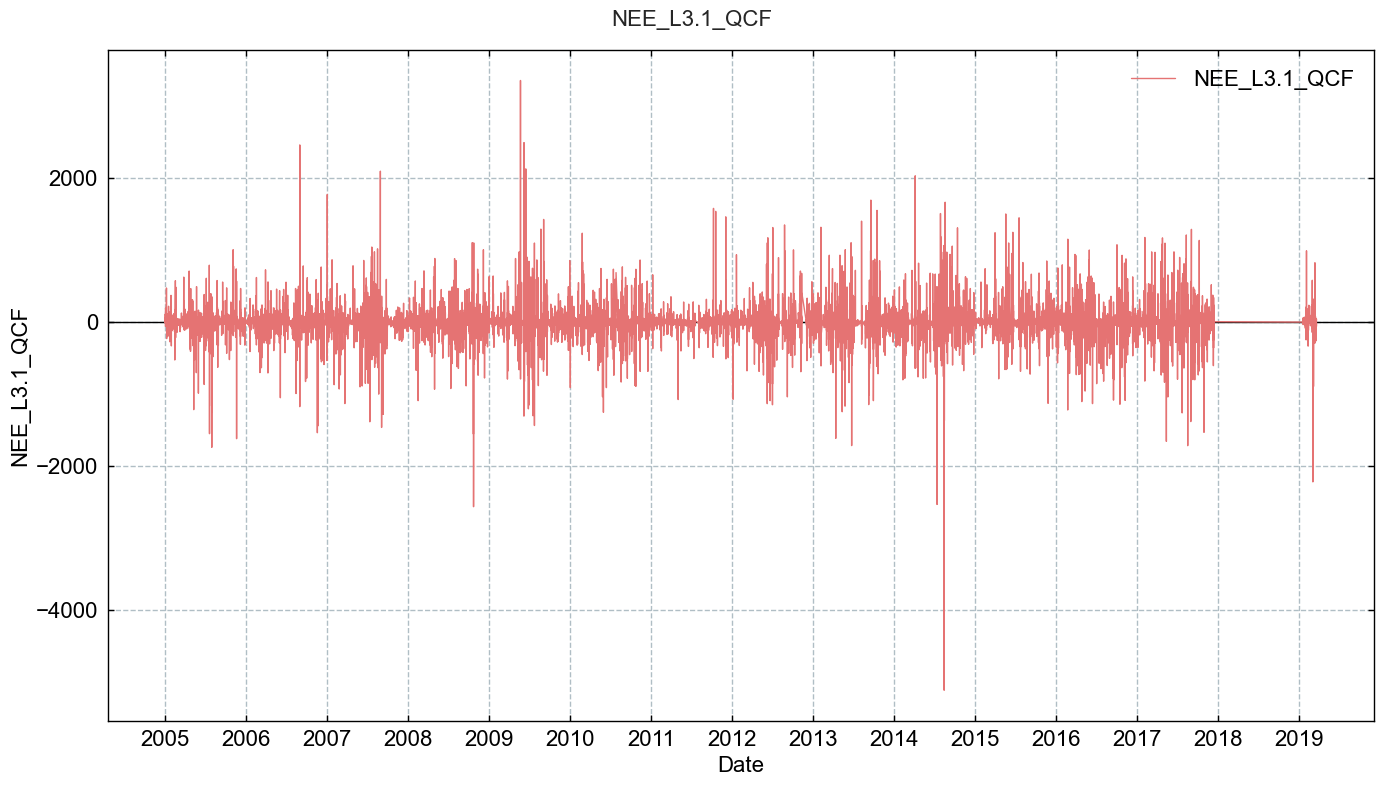

In [41]:
# TimeSeries(series=fpc.fpc_df[fpc.filteredseries.name]).plot_interactive()
TimeSeries(series=fpc.fpc_df[fpc.filteredseries.name]).plot()

</br>

## Initiate calculations

In [42]:
fpc.level32_stepwise_outlier_detection()

</br>

</br>

## Outlier flag: **Absolute limits**
- remove values outside a physically plausible range
- typical value for CO2 flux `FC`: +/-50 µmol m-2 s-1
- typical value for latent evaporation flux `LE`: +800 / -50 W m-2
- typical value for sensible heat flux `H`: +400 / -200 W m-2

In [43]:
# from diive.pkgs.outlierdetection.absolutelimits import AbsoluteLimits
# help(AbsoluteLimits)

[AbsoluteLimits]  running AbsoluteLimits ...


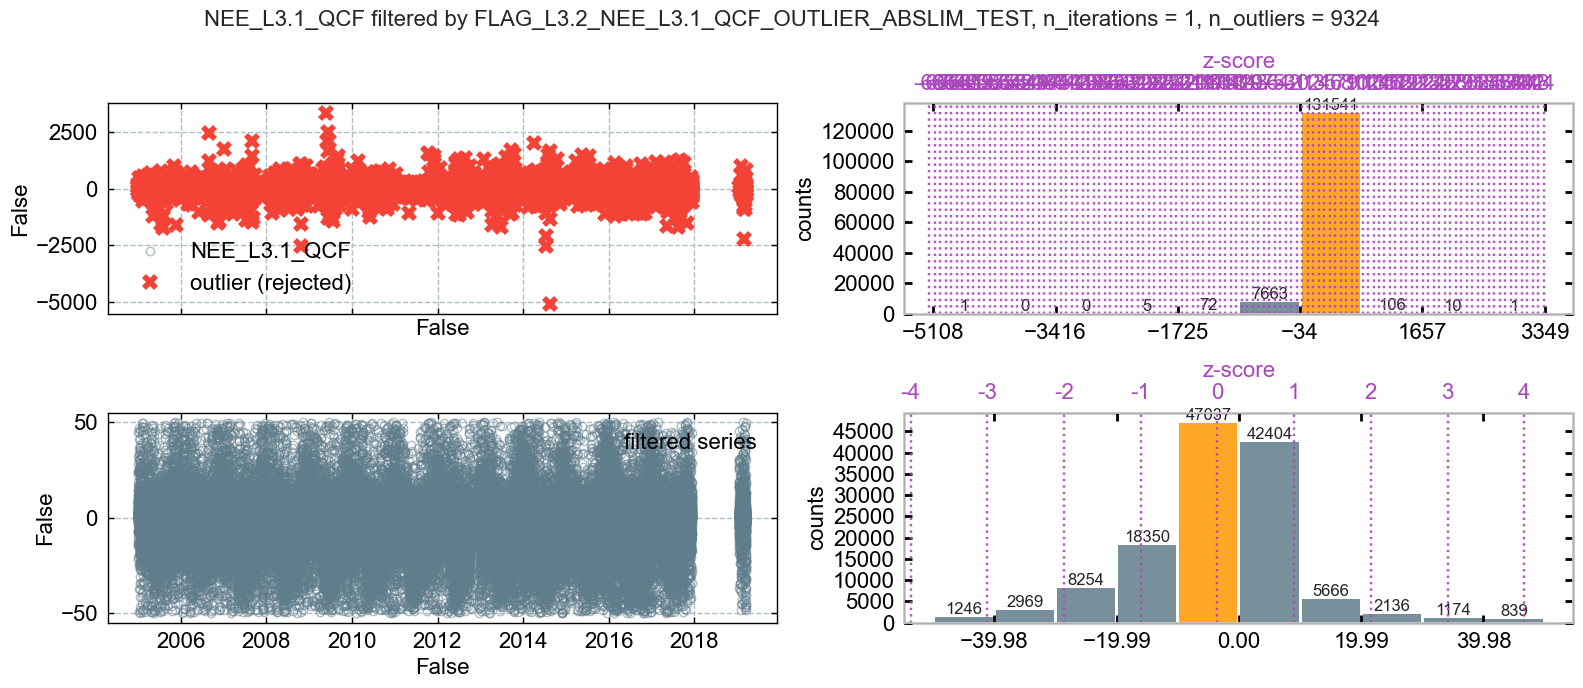

In [44]:
MIN = -50
MAX = 50
fpc.level32_flag_outliers_abslim_test(minval=MIN, maxval=MAX, showplot=True, verbose=True)

In [45]:
fpc.level32_addflag()

++Added flag column FLAG_L3.2_NEE_L3.1_QCF_OUTLIER_ABSLIM_TEST to flag data


</br>

</br>

## Outlier flag: **Manual flag**
- The interactive plot can be used to determine the exact start and end of time ranges or data points that need to be removed, e.g. due to known instrument failure

In [46]:
# from diive.pkgs.outlierdetection.manualremoval import ManualRemoval
# help(ManualRemoval)

In [47]:
# fpc.level32.showplot_cleaned(interactive=True)  # True or False
# fpc.level32.showplot_cleaned(interactive=False)  # True or False

In [48]:
# # Removes date range between two datetimes (inclusive)
# REMOVE_DATES = [    
#     ['2008-12-01', '2009-05-01']
# ]
# fpc.level32_flag_manualremoval_test(
#     remove_dates=REMOVE_DATES,
#     showplot=True, verbose=True)

In [49]:
# fpc.level32_addflag()

In [50]:
# fpc.level32.showplot_cleaned(interactive=True)  # True or False

</br>

</br>

## Outlier flag: **Hampel filter**, separate for daytime and nighttime
- Recommended filter
- Is slow compared to other filters:
    - tested with 1 year of 30MIN time resolution data and it needed approx. 43 seconds on a fast desktop computer

In [51]:
# from diive.pkgs.outlierdetection.hampel import Hampel
# help(Hampel)

[HampelDaytimeNighttime]  running HampelDaytimeNighttime ...
ITERATION#1: Total found outliers: 9505 (daytime+nighttime), 2789 (daytime), 6716 (nighttime)
ITERATION#2: Total found outliers: 1243 (daytime+nighttime), 334 (daytime), 909 (nighttime)
ITERATION#3: Total found outliers: 266 (daytime+nighttime), 57 (daytime), 209 (nighttime)
ITERATION#4: Total found outliers: 74 (daytime+nighttime), 19 (daytime), 55 (nighttime)
ITERATION#5: Total found outliers: 18 (daytime+nighttime), 3 (daytime), 15 (nighttime)
ITERATION#6: Total found outliers: 6 (daytime+nighttime), 0 (daytime), 6 (nighttime)
ITERATION#7: Total found outliers: 1 (daytime+nighttime), 0 (daytime), 1 (nighttime)
ITERATION#8: Total found outliers: 1 (daytime+nighttime), 0 (daytime), 1 (nighttime)
ITERATION#9: Total found outliers: 0 (daytime+nighttime), 0 (daytime), 0 (nighttime)
CPU times: total: 14min 15s
Wall time: 14min 57s


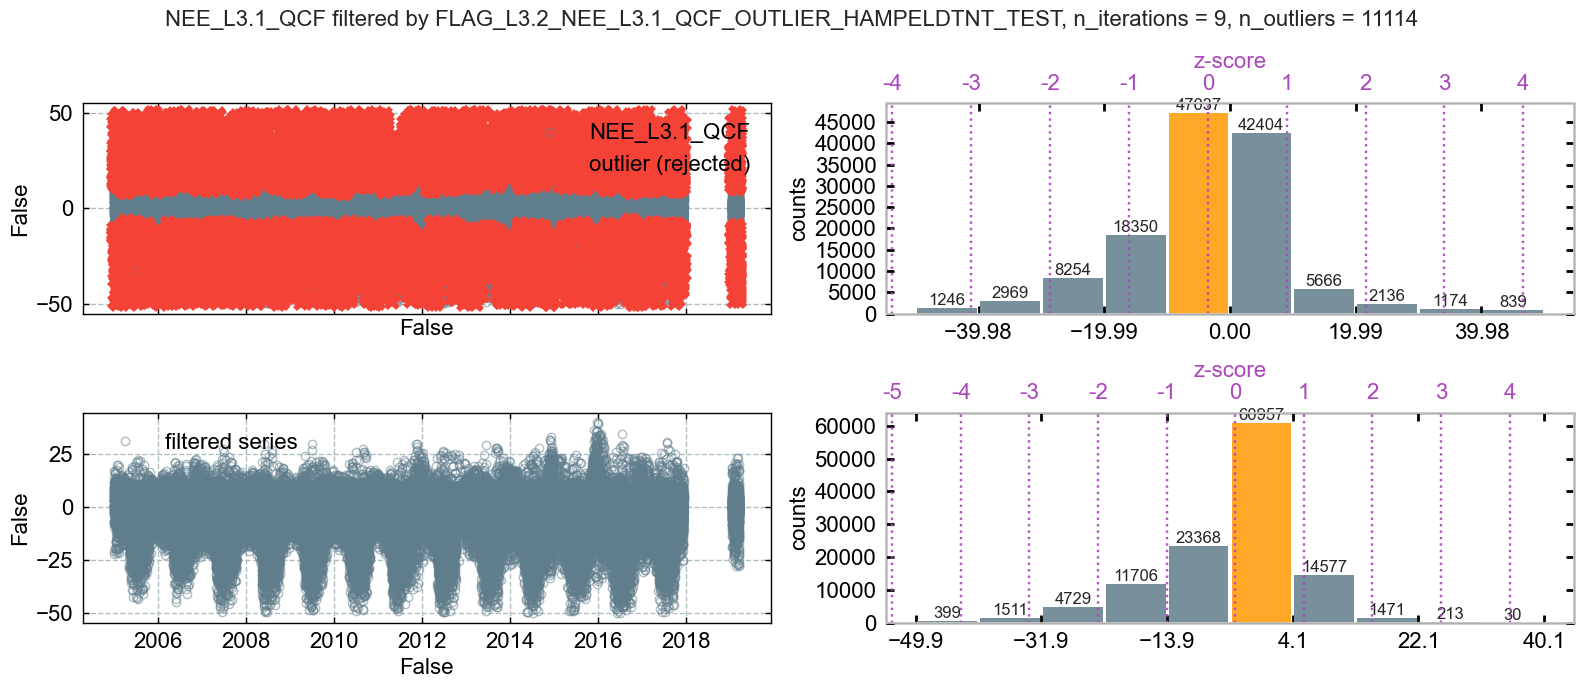

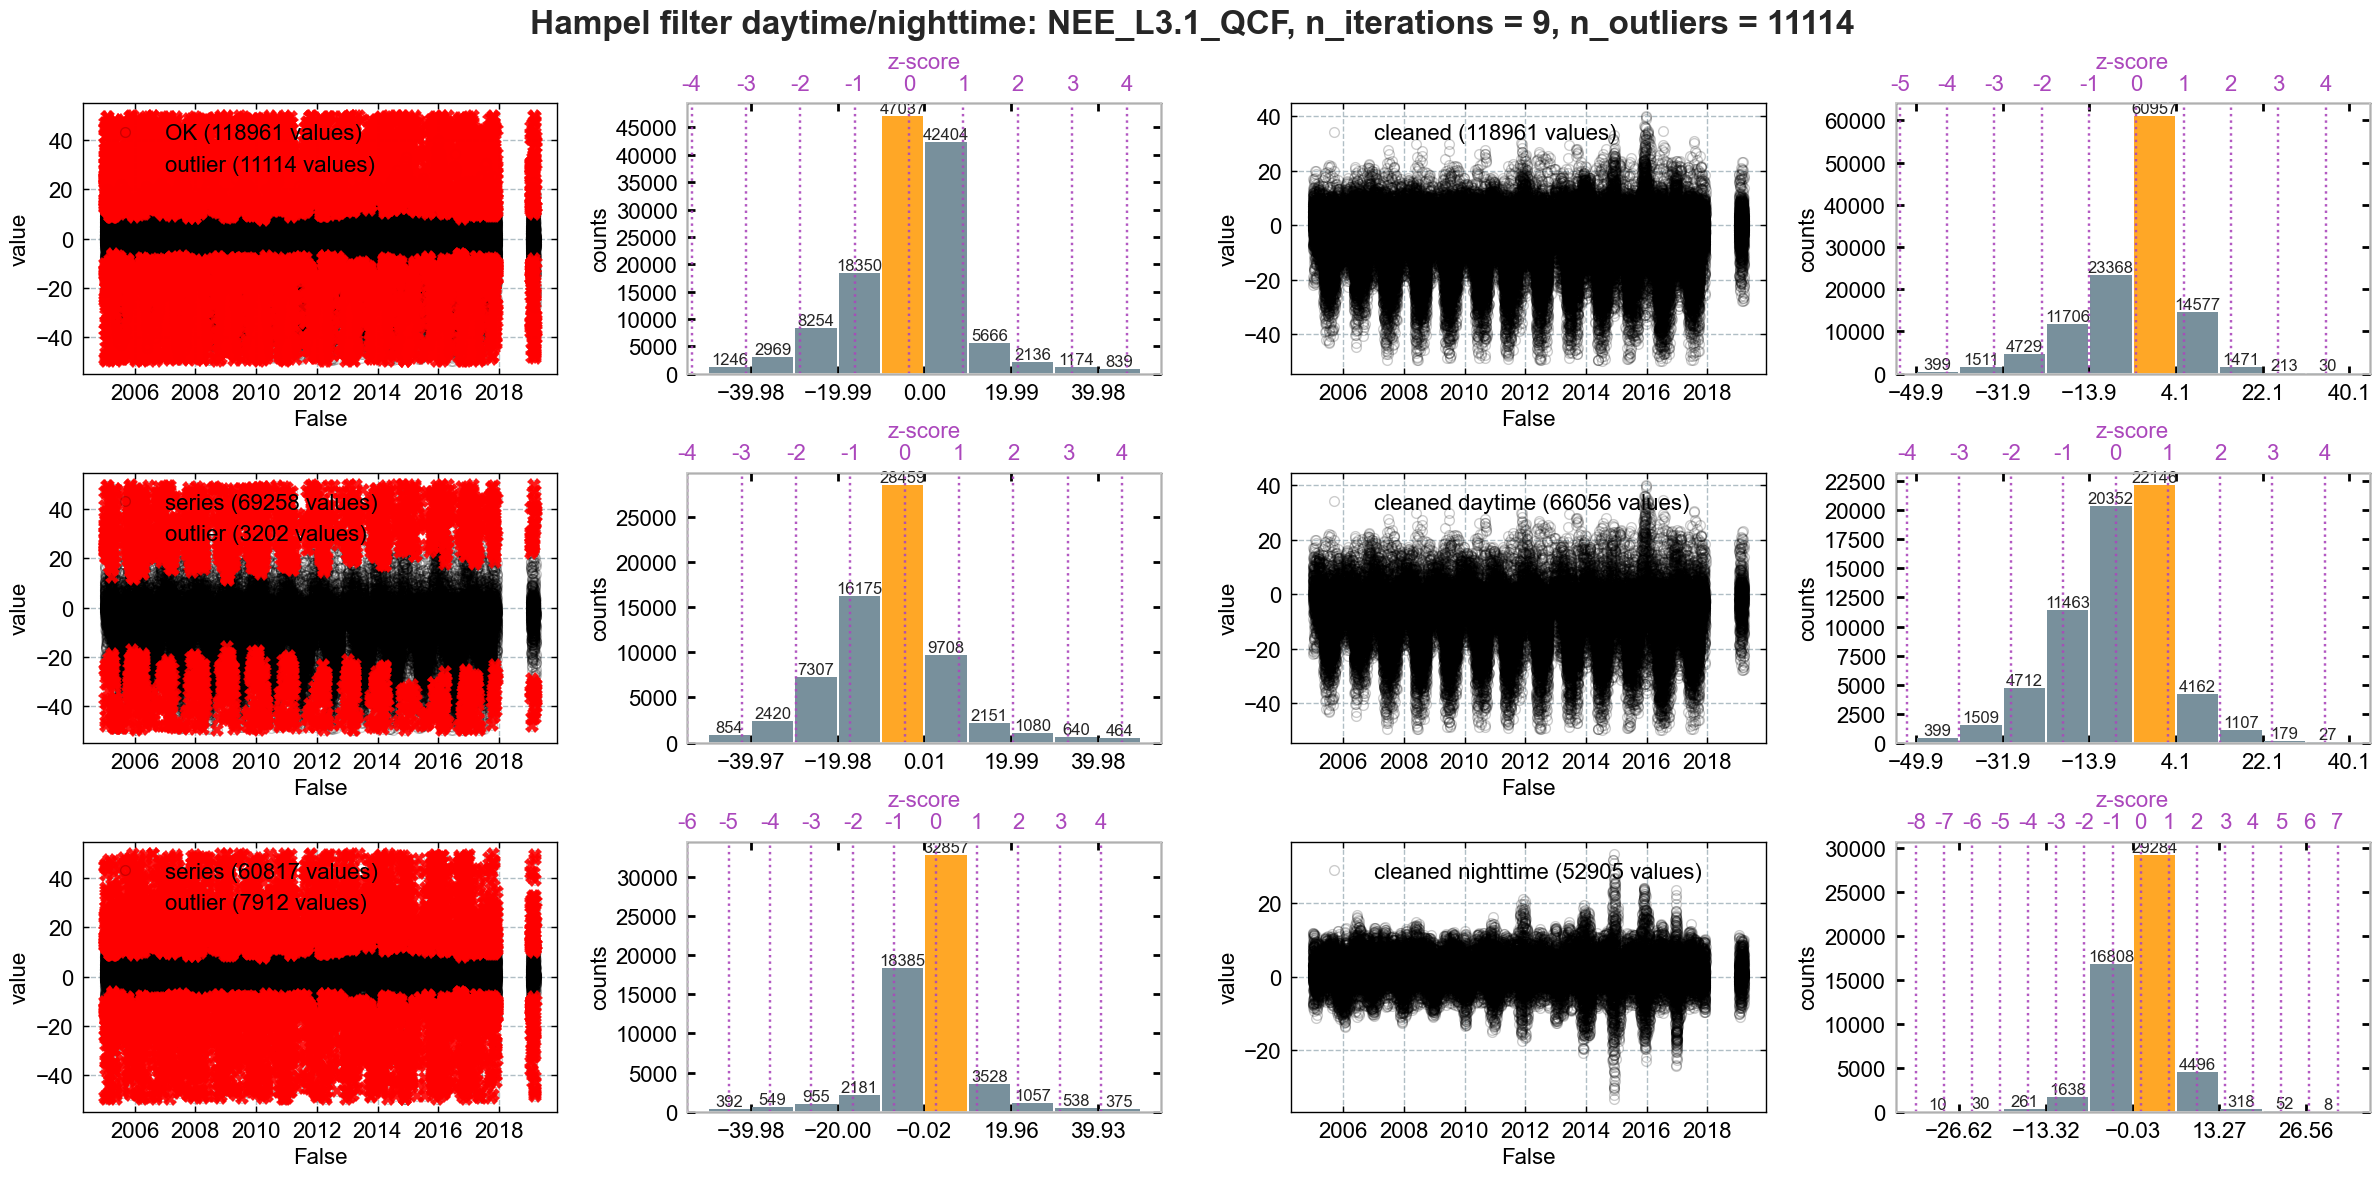

In [52]:
%%time
WINDOW_LENGTH = 48 * 13
N_SIGMA_DT = 3.5
N_SIGMA_NT = 3.5
fpc.level32_flag_outliers_hampel_dtnt_test(window_length=WINDOW_LENGTH, n_sigma_dt=N_SIGMA_DT, n_sigma_nt=N_SIGMA_NT,
                                           showplot=True, verbose=True, repeat=True)

In [53]:
fpc.level32_addflag()

++Added flag column FLAG_L3.2_NEE_L3.1_QCF_OUTLIER_HAMPELDTNT_TEST to flag data


</br>

</br>

## Outlier flag: **z-score across all data**

In [ ]:
# from diive.pkgs.outlierdetection.zscore import zScore
# help(zScore)

In [ ]:
# THRES_ZSCORE = 6
# fpc.level32_flag_outliers_zscore_test(thres_zscore=THRES_ZSCORE, showplot=True, verbose=True, repeat=True)

In [ ]:
# fpc.level32_addflag()

</br>

</br>

## Outlier flag: **Hampel filter**
- Recommended filter
- Is slow compared to other filters:
    - tested with 1 year of 30MIN time resolution data and it needed approx. 33 seconds on a fast desktop computer
    - tested with 19 years of 30MIN time resolution data and it needed approx. 20 minutes on a fast desktop computer

In [ ]:
# from diive.pkgs.outlierdetection.hampel import Hampel
# help(Hampel)

In [ ]:
# WINDOW_LENGTH = 48 * 13
# N_SIGMA = 6
# %%time
# fpc.level32_flag_outliers_hampel_test(window_length=WINDOW_LENGTH, n_sigma=N_SIGMA, showplot=True, verbose=True, repeat=True)

In [ ]:
# fpc.level32_addflag()

</br>

</br>

## Outlier flag: **z-score over all data**, separate for daytime and nighttime

In [ ]:
# from diive.pkgs.outlierdetection.zscore import zScoreDaytimeNighttime
# help(zScoreDaytimeNighttime)

[zScoreDaytimeNighttime]  running zScoreDaytimeNighttime ...
ITERATION#1: Total found outliers: 218 (daytime+nighttime), 7 (daytime), 211 (nighttime)
ITERATION#2: Total found outliers: 65 (daytime+nighttime), 0 (daytime), 65 (nighttime)
ITERATION#3: Total found outliers: 14 (daytime+nighttime), 0 (daytime), 14 (nighttime)
ITERATION#4: Total found outliers: 7 (daytime+nighttime), 0 (daytime), 7 (nighttime)
ITERATION#5: Total found outliers: 4 (daytime+nighttime), 0 (daytime), 4 (nighttime)
ITERATION#6: Total found outliers: 1 (daytime+nighttime), 0 (daytime), 1 (nighttime)
ITERATION#7: Total found outliers: 1 (daytime+nighttime), 0 (daytime), 1 (nighttime)
ITERATION#8: Total found outliers: 0 (daytime+nighttime), 0 (daytime), 0 (nighttime)


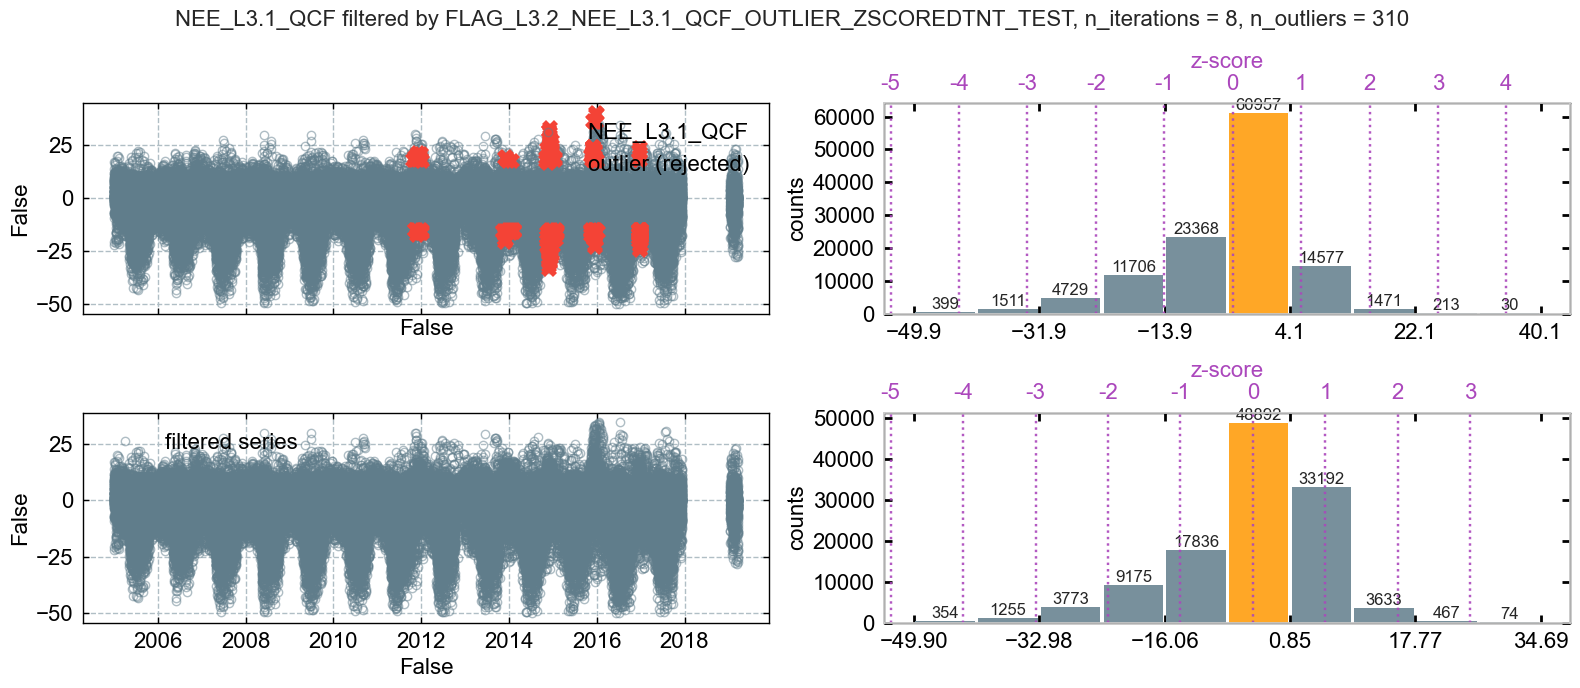

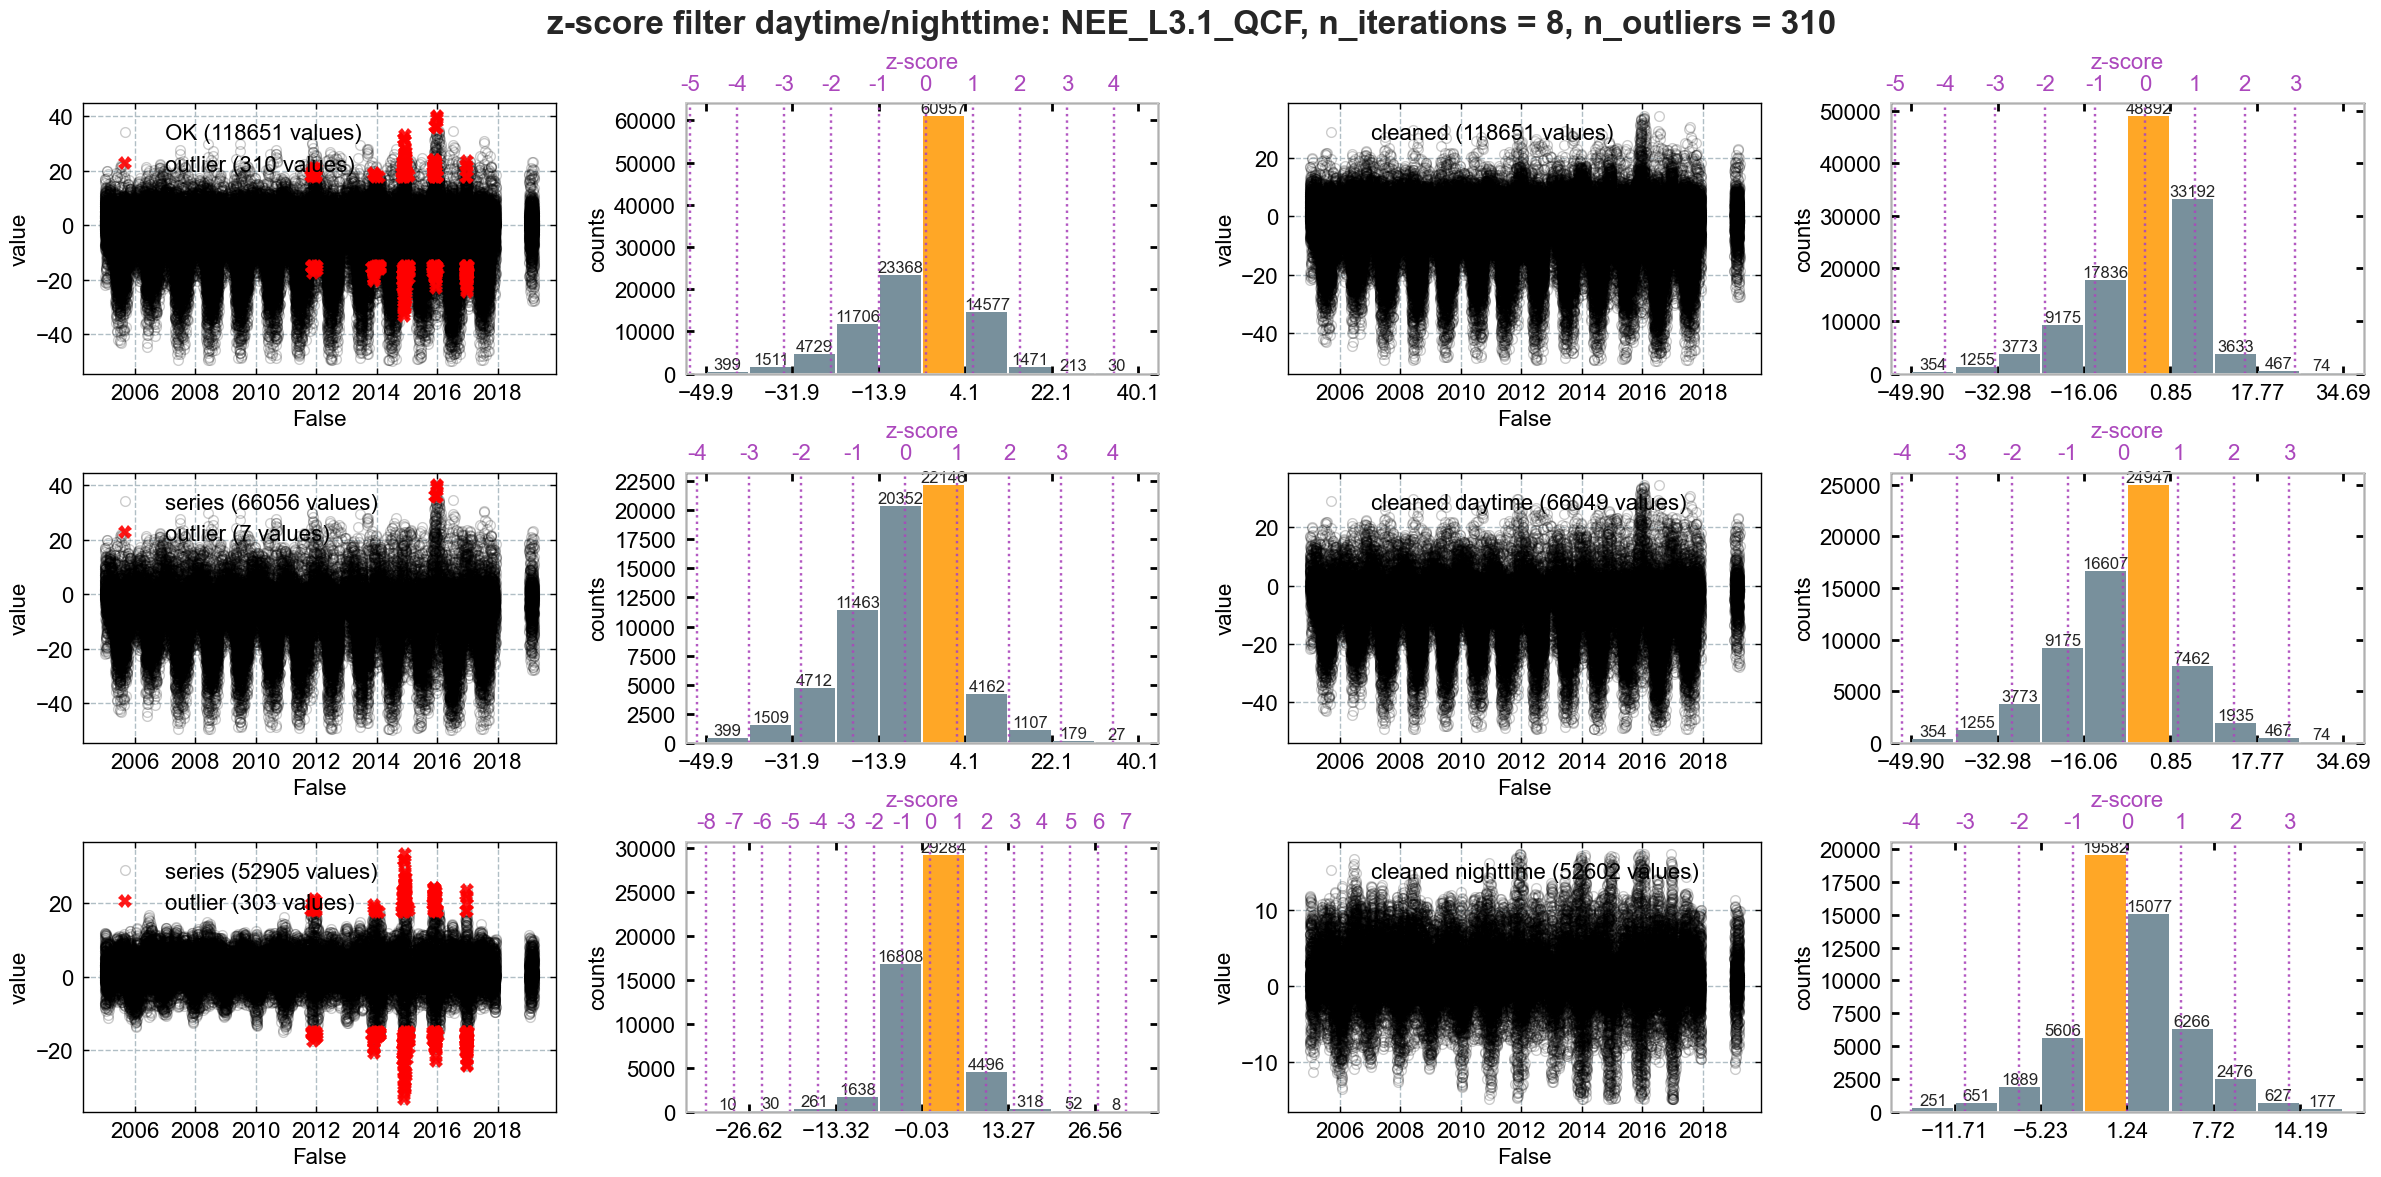

In [55]:
THRES_ZSCORE = 4
fpc.level32_flag_outliers_zscore_dtnt_test(thres_zscore=THRES_ZSCORE, showplot=True, verbose=True, repeat=True)

In [56]:
fpc.level32_addflag()

++Added flag column FLAG_L3.2_NEE_L3.1_QCF_OUTLIER_ZSCOREDTNT_TEST to flag data


</br>

</br>

## Outlier flag: **Rolling z-score over all data**

In [57]:
# from diive.pkgs.outlierdetection.zscore import zScoreRolling
# help(zScoreRolling)

[zScoreRolling]  running zScoreRolling ...
ITERATION#1: Total found outliers: 162 values
ITERATION#2: Total found outliers: 55 values
ITERATION#3: Total found outliers: 17 values
ITERATION#4: Total found outliers: 5 values
ITERATION#5: Total found outliers: 1 values
ITERATION#6: Total found outliers: 0 values


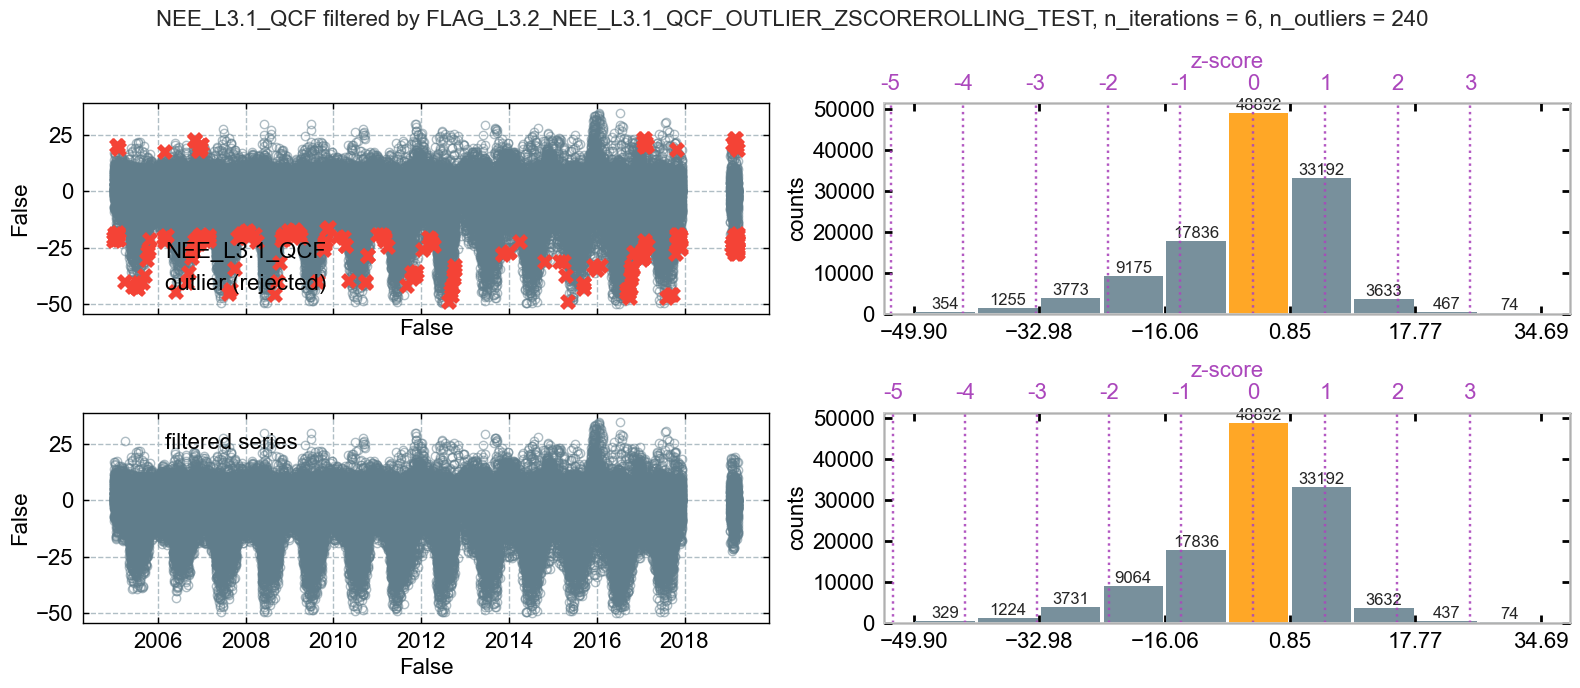

In [58]:
THRES_ZSCORE = 3.5
WINSIZE = 48 * 21
fpc.level32_flag_outliers_zscore_rolling_test(winsize=WINSIZE, thres_zscore=THRES_ZSCORE, showplot=True, verbose=True, repeat=True)

In [59]:
fpc.level32_addflag()

++Added flag column FLAG_L3.2_NEE_L3.1_QCF_OUTLIER_ZSCOREROLLING_TEST to flag data


</br>

</br>

## Outlier flag: **Local standard deviation**, with rolling median and *rolling* standard deviation

In [ ]:
# from diive.pkgs.outlierdetection.localsd import LocalSD
# help(LocalSD)

In [ ]:
# N_SD = 3.5
# WINSIZE = 48 * 13
# fpc.level32_flag_outliers_localsd_test(n_sd=N_SD, winsize=WINSIZE, constant_sd=False, showplot=True, verbose=True, repeat=True)

In [ ]:
fpc.level32_addflag()

</br>

</br>

## Outlier flag: **Local standard deviation**, with rolling median and *constant* standard deviation
- keep standard deviation constant by setting parameter `constant_sd=True`

In [ ]:
# N_SD = 4
# WINSIZE = 48 * 365
# fpc.level32_flag_outliers_localsd_test(n_sd=N_SD, winsize=WINSIZE, constant_sd=True, showplot=True, verbose=True, repeat=True)

In [ ]:
# fpc.level32_addflag()

</br>

</br>

## Outlier flag: **Increments z-score**

In [ ]:
# from diive.pkgs.outlierdetection.incremental import zScoreIncrements
# help(zScoreIncrements)

In [ ]:
# THRES_ZSCORE = 4
# fpc.level32_flag_outliers_increments_zcore_test(thres_zscore=THRES_ZSCORE, showplot=True, verbose=True, repeat=True)

In [ ]:
# fpc.level32_addflag()

</br>

</br>

## Outlier flag: **Local outlier factor**, daytime/nighttime
- Test is run separately for daytime and nighttime data
- Description of local outlier factor: [here](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html)

In [ ]:
# from diive.pkgs.outlierdetection.lof import LocalOutlierFactorDaytimeNighttime
# help(LocalOutlierFactorDaytimeNighttime)

In [ ]:
# N_NEIGHBORS = None
# CONTAMINATION = None
# fpc.level32_flag_outliers_lof_dtnt_test(n_neighbors=N_NEIGHBORS, contamination=CONTAMINATION, showplot=True, verbose=True, repeat=False, n_jobs=-1)

In [ ]:
# fpc.level32_addflag()

</br>

</br>

## Outlier flag: **Local outlier factor**
- Test is run across all data
- Description of local outlier factor: [here](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html)

In [ ]:
# from diive.pkgs.outlierdetection.lof import LocalOutlierFactorAllData
# help(LocalOutlierFactorAllData)

In [ ]:
# N_NEIGHBORS = 24
# CONTAMINATION = None
# fpc.level32_flag_outliers_lof_test(n_neighbors=N_NEIGHBORS, contamination=CONTAMINATION, showplot=True, verbose=True, repeat=False, n_jobs=-1)

In [ ]:
# fpc.level32_addflag()

</br>

</br>

## Outlier flag: **Absolute limits**, separate for daytime and nighttime data

In [ ]:
# from diive.pkgs.outlierdetection.absolutelimits import AbsoluteLimitsDaytimeNighttime
# help(AbsoluteLimitsDaytimeNighttime)

In [ ]:
# MIN_DT = -50
# MAX_DT = 50
# MIN_NT = -25
# MAX_NT = 25
# fpc.level32_flag_outliers_abslim_dtnt_test(daytime_minmax=[MIN_DT, MAX_DT], nighttime_minmax=[MIN_NT, MAX_NT], showplot=True, verbose=True)

In [ ]:
# fpc.level32_addflag()

</br>

</br>

## Outlier flag: **Trim nighttime flux data**

In [ ]:
# from diive.pkgs.outlierdetection.trim import TrimLow
# help(TrimLow)

In [ ]:
# fpc.level32_flag_outliers_trim_low_test(trim_nighttime=True, lower_limit=-5, showplot=True, verbose=True)

In [ ]:
# fpc.level32_addflag()

</br>

</br>

## **Finalize Level-3.2**: Calculate overall quality flag (so far)

In [60]:
fpc.finalize_level32()

++Added new column FLAG_L3.2_NEE_L3.1_QCF_OUTLIER_ABSLIM_TEST.
++Added new column FLAG_L3.2_NEE_L3.1_QCF_OUTLIER_HAMPELDTNT_TEST.
++Added new column FLAG_L3.2_NEE_L3.1_QCF_OUTLIER_ZSCOREDTNT_TEST.
++Added new column FLAG_L3.2_NEE_L3.1_QCF_OUTLIER_ZSCOREROLLING_TEST.
++Added new column SUM_L3.2_NEE_L3.1_HARDFLAGS.
++Added new column SUM_L3.2_NEE_L3.1_SOFTFLAGS.
++Added new column SUM_L3.2_NEE_L3.1_FLAGS.
++Added new column FLAG_L3.2_NEE_L3.1_QCF.
++Added new column NEE_L3.1_L3.2_QCF.
++Added new column NEE_L3.1_L3.2_QCF0.


</br>

### Available `Level-3.2` variables
- This shows all available Level-3.2 variables for this flux

In [61]:
[x for x in fpc.fpc_df.columns if 'L3.2' in x]

['FLAG_L3.2_NEE_L3.1_QCF_OUTLIER_ABSLIM_TEST',
 'FLAG_L3.2_NEE_L3.1_QCF_OUTLIER_HAMPELDTNT_TEST',
 'FLAG_L3.2_NEE_L3.1_QCF_OUTLIER_ZSCOREDTNT_TEST',
 'FLAG_L3.2_NEE_L3.1_QCF_OUTLIER_ZSCOREROLLING_TEST',
 'SUM_L3.2_NEE_L3.1_HARDFLAGS',
 'SUM_L3.2_NEE_L3.1_SOFTFLAGS',
 'SUM_L3.2_NEE_L3.1_FLAGS',
 'FLAG_L3.2_NEE_L3.1_QCF',
 'NEE_L3.1_L3.2_QCF',
 'NEE_L3.1_L3.2_QCF0']

</br>

### Plot filtered flux after Level-3.2
In the four panels, from left to right:
- flux after Level-3.1, before outlier removal
- flux after Level-3.2, after outlier removal
- sum of the individual test flags
- overall flag `QCF` (quality control flag), where `0`=best quality, `1`=medium quality, `2`=bad quality  

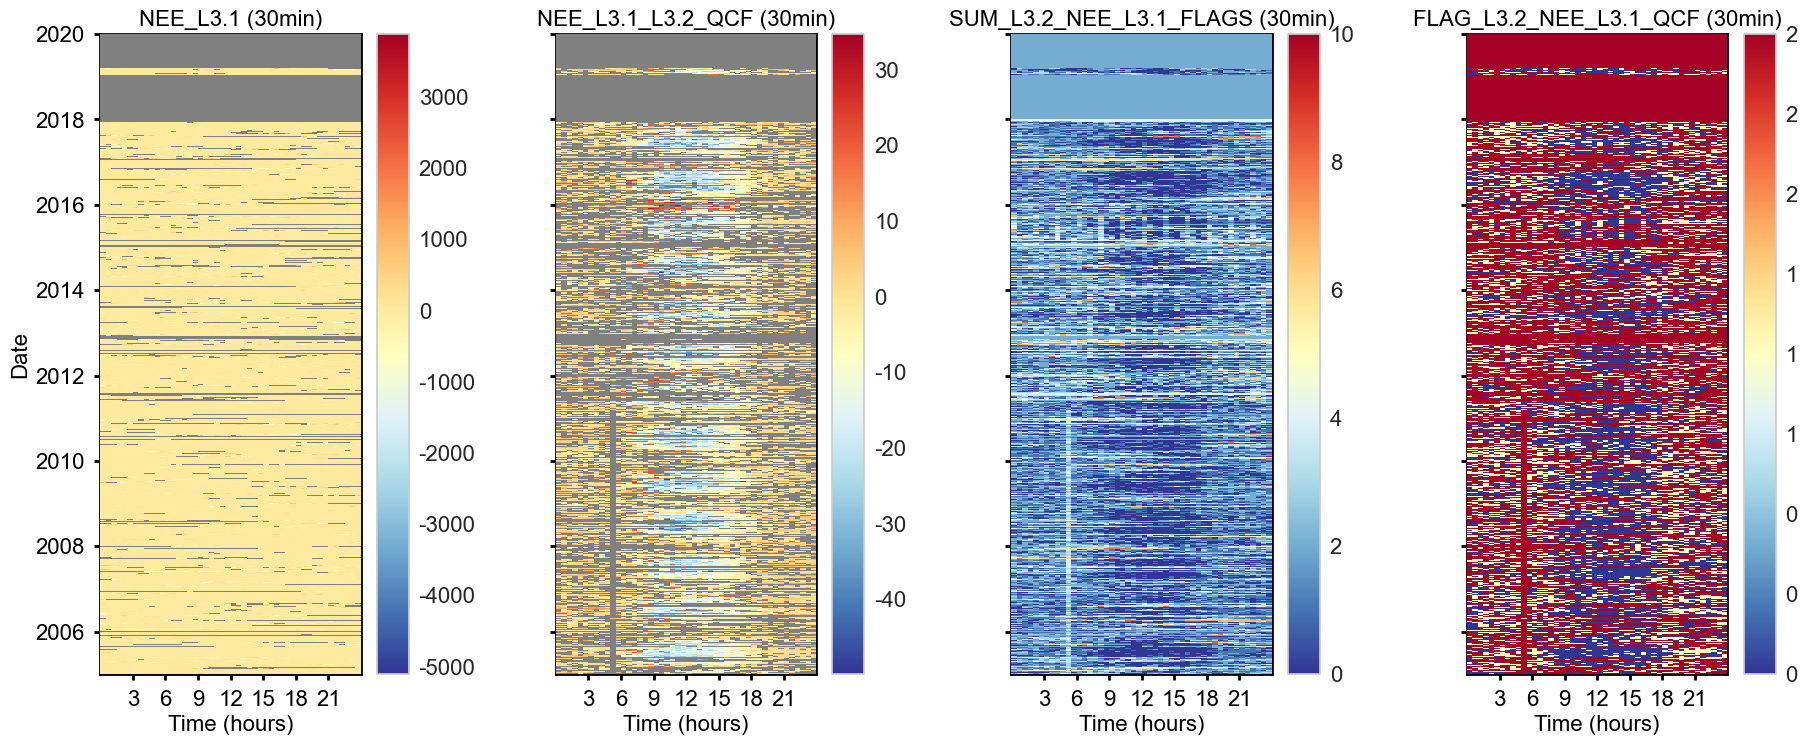

In [62]:
fpc.level32_qcf.showplot_qcf_heatmaps()

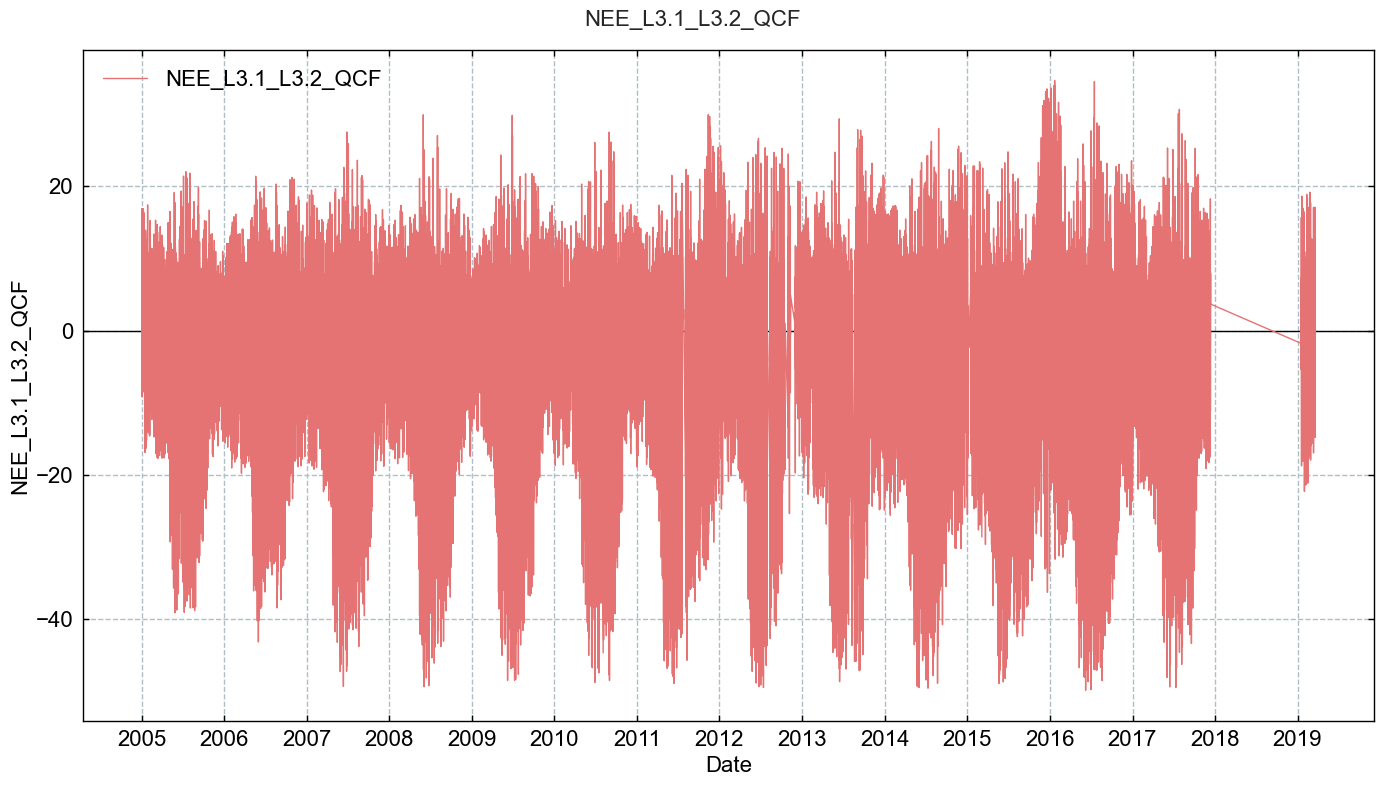

In [63]:
TimeSeries(series=fpc.filteredseries).plot()
# TimeSeries(series=fpc.filteredseries).plot_interactive()

In [64]:
# fpc.level32_qcf.showplot_qcf_timeseries()

</br>

### Reports

In [65]:
fpc.level32_qcf.report_qcf_evolution()



QCF FLAG EVOLUTION
This output shows the evolution of the QCF overall quality flag
when test flags are applied sequentially to the variable NEE_L3.1.

Number of NEE_L3.1 records before QC: 207547
+++ FLAG_L2_FC_MISSING_TEST rejected 0 values (+0.00%)      TOTALS: flag 0: 207547 (100.00%) / flag 1: 0 (0.00%) / flag 2: 0 (0.00%)
+++ FLAG_L2_FC_SSITC_TEST rejected 46180 values (+22.25%)      TOTALS: flag 0: 76967 (37.08%) / flag 1: 84400 (40.67%) / flag 2: 46180 (22.25%)
+++ FLAG_L2_FC_COMPLETENESS_TEST rejected 2049 values (+0.99%)      TOTALS: flag 0: 74743 (36.01%) / flag 1: 84575 (40.75%) / flag 2: 48229 (23.24%)
+++ FLAG_L2_FC_SCF_TEST rejected 0 values (+0.00%)      TOTALS: flag 0: 74743 (36.01%) / flag 1: 84575 (40.75%) / flag 2: 48229 (23.24%)
+++ FLAG_L2_FC_SIGNAL_STRENGTH_TEST rejected 10384 values (+5.00%)      TOTALS: flag 0: 71770 (34.58%) / flag 1: 77164 (37.18%) / flag 2: 58613 (28.24%)
+++ FLAG_L2_FC_CO2_VM97_SPIKE_HF_TEST rejected 1876 values (+0.90%)      TOTALS: flag 

In [66]:
fpc.level32_qcf.report_qcf_series()



SUMMARY: FLAG_L3.2_NEE_L3.1_QCF, QCF FLAG FOR NEE_L3.1
Between 2005-01-01 00:15 and 2019-12-31 23:45 ...
    Total flux records BEFORE quality checks: 207547 (78.93% of potential)
    Available flux records AFTER quality checks: 118411 (57.05% of total)
    Rejected flux records: 89136 (42.95% of total)
    Potential flux records: 262944
    Potential flux records missed: 55397 (21.07% of potential)



In [67]:
fpc.level32_qcf.report_qcf_flags()


REPORT: FLAGS INCL. MISSING VALUES
Stats with missing values in the dataset
FLAG_L2_FC_MISSING_TEST:
    OVERALL flag 0.0: 207547 values (78.93%)  
    OVERALL flag 2.0: 55397 values (21.07%)  
    OVERALL flag missing: 0 values (0.00%)  

    DAYTIME flag 0.0: 102112 values (79.03%)  
    DAYTIME flag 2.0: 27101 values (20.97%)  
    DAYTIME flag missing: 0 values (0.00%)  

    NIGHTTIME flag 0.0: 105435 values (78.84%)  
    NIGHTTIME flag 2.0: 28296 values (21.16%)  
    NIGHTTIME flag missing: 0 values (0.00%)  

FLAG_L2_FC_SSITC_TEST:
    OVERALL flag 0.0: 76995 values (29.28%)  
    OVERALL flag 1.0: 84450 values (32.12%)  
    OVERALL flag 2.0: 46210 values (17.57%)  
    OVERALL flag missing: 55289 values (21.03%)  

    DAYTIME flag 0.0: 50406 values (39.01%)  
    DAYTIME flag 1.0: 35390 values (27.39%)  
    DAYTIME flag 2.0: 16343 values (12.65%)  
    DAYTIME flag missing: 27074 values (20.95%)  

    NIGHTTIME flag 0.0: 26589 values (19.88%)  
    NIGHTTIME flag 1.0: 49

</br>

## Save Level-3.2 results to file
- If needed, save results so far (input data and all created variables, e.g. flags and filtered fluxes) to a file
- This can be useful if e.g. USTAR filtering is not needed and gap-filling is done elsewhere (ReddyProc...)

In [68]:
results_df = fpc.get_data()
filename = "31.5_FluxProcessingChain_after-L3.2_NEE_QCF11"
results_df.to_csv(f"{filename}.csv", index=True)
save_parquet(data=results_df, filename=filename)

NEW VARIABLES FROM FLUX PROCESSING CHAIN:
++ FLAG_L2_FC_MISSING_TEST
++ FLAG_L2_FC_SSITC_TEST
++ FLAG_L2_FC_COMPLETENESS_TEST
++ FLAG_L2_FC_SCF_TEST
++ FLAG_L2_FC_SIGNAL_STRENGTH_TEST
++ FLAG_L2_FC_CO2_VM97_SPIKE_HF_TEST
++ FLAG_L2_FC_CO2_VM97_AMPLITUDE_RESOLUTION_HF_TEST
++ FLAG_L2_FC_CO2_VM97_DROPOUT_TEST
++ SUM_L2_FC_HARDFLAGS
++ SUM_L2_FC_SOFTFLAGS
++ SUM_L2_FC_FLAGS
++ FLAG_L2_FC_QCF
++ FC_L2_QCF
++ FC_L2_QCF0
++ SC_SINGLE_gfRMED_L3.1
++ FLAG_SC_SINGLE_gfRMED_L3.1_ISFILLED
++ NEE_L3.1
++ NEE_L3.1_QCF
++ NEE_L3.1_QCF0
++ FLAG_L3.2_NEE_L3.1_QCF_OUTLIER_ABSLIM_TEST
++ FLAG_L3.2_NEE_L3.1_QCF_OUTLIER_HAMPELDTNT_TEST
++ FLAG_L3.2_NEE_L3.1_QCF_OUTLIER_ZSCOREDTNT_TEST
++ FLAG_L3.2_NEE_L3.1_QCF_OUTLIER_ZSCOREROLLING_TEST
++ SUM_L3.2_NEE_L3.1_HARDFLAGS
++ SUM_L3.2_NEE_L3.1_SOFTFLAGS
++ SUM_L3.2_NEE_L3.1_FLAGS
++ FLAG_L3.2_NEE_L3.1_QCF
++ NEE_L3.1_L3.2_QCF
++ NEE_L3.1_L3.2_QCF0
No variables in input data were overwritten, only new variables added.
Saved file 31.1_FluxProcessingChain_after-L3

'31.1_FluxProcessingChain_after-L3.2_NEE_QCF10.parquet'

</br>

</br>

# **End of notebook**

---

Congratulations, you reached the end of this notebook! Before you go let's store your finish time.

In [69]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-10-26 21:51:06
